# Newsdata based digital maturity assessment

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Import des CSV Mapping Files und der Ordnerstruktur mit den Exports von YukkaLab

In [82]:
#Speicherort der CSVs
import os
import pandas as pd

# Main folder containing subfolders for each company
main_path = '/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/Yukkalab Daten/Analysis_Data_Final_STOXX600'  # Update this with the path to your main folder

# Load the Excel file with company names and supersectors
excel_path = "/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/Yukkalab Daten/Stoxx_600_Full.xlsx" # Update this with the path to your Excel file
company_info_df = pd.read_excel(excel_path)

# Initialize an empty list to store DataFrames from each subfolder
df_list = []

# Iterate through each subfolder
for subfolder in os.listdir(main_path):
    subfolder_path = os.path.join(main_path, subfolder)
    if os.path.isdir(subfolder_path):
        all_files = [os.path.join(subfolder_path, f) for f in os.listdir(subfolder_path) if f.endswith('.csv')]
        
        for file in all_files:
            practice_df = pd.read_csv(file)
            practice_df['date'] = pd.to_datetime(practice_df['date'])
            practice_df['practice'] = os.path.basename(file).split('.')[0]
            practice_df['subfolder_name'] = subfolder  # Add the subfolder name to the DataFrame
            df_list.append(practice_df)

# Concatenate all DataFrames
df = pd.concat(df_list)
df.sort_values(by=['practice', 'date'], inplace=True)

# Join with company_info_df to add company name and supersector
df = df.merge(company_info_df, left_on='subfolder_name', right_on='Subfolder Name', how='left')


### aktuelle Version des CSV File base merges

In [1]:
import os
import pandas as pd

# Pfadangaben aktualisieren
main_path = '/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/Yukkalab Daten/Analysis_Data_Final_STOXX600'
excel_path = "/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/Yukkalab Daten/Stoxx_600_Full.xlsx"
company_info_df = pd.read_excel(excel_path)

# Liste zur Speicherung der DataFrames aus jedem Subordner
df_list = []

# Zähler für die Unternehmen
company_no = 1

# Durchlaufen jedes Subordners
for subfolder in sorted(os.listdir(main_path)):
    subfolder_path = os.path.join(main_path, subfolder)
    if os.path.isdir(subfolder_path):
        all_files = [os.path.join(subfolder_path, f) for f in os.listdir(subfolder_path) if f.endswith('.csv')]
        
        for file in all_files:
            practice_df = pd.read_csv(file)
            practice_df['date'] = pd.to_datetime(practice_df['date'])
            practice_df['practice'] = os.path.basename(file).split('.')[0]
            practice_df['subfolder_name'] = subfolder
            # Füge die Unternehmensnummer zum DataFrame hinzu
            practice_df['Company No'] = company_no
            df_list.append(practice_df)
        
        # Zähler nach der Verarbeitung jedes Subfolders inkrementieren
        company_no += 1

# Zusammenführen aller DataFrames
df = pd.concat(df_list)
df.sort_values(by=['practice', 'date'], inplace=True)

# Verknüpfung mit company_info_df, um Unternehmensnamen und Supersektor hinzuzufügen
df = df.merge(company_info_df, left_on='subfolder_name', right_on='Subfolder Name', how='left')


In [3]:
df.size

1535699200

In [ ]:
import os
import pandas as pd

# Pfad zum Ordner mit den Volumendaten
volume_path = '/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/Yukkalab Daten/volumes'

# Liste für die gesammelten Daten
data_list = []

# Initialisiere den Unternehmenszähler
company_no = 1

# Durchlaufe alle Dateien im angegebenen Verzeichnis
for file_name in sorted(os.listdir(volume_path)):
    if file_name.endswith('.csv'):
        # Extrahiere den Unternehmensnamen aus dem Dateinamen (ohne ".csv")
        company_name = file_name[:-4]
        
        # Vollständiger Pfad zur CSV-Datei
        file_path = os.path.join(volume_path, file_name)
        
        # Lade die CSV-Datei
        df_2 = pd.read_csv(file_path)
        
        # Umwandeln der 'date'-Spalte in ein Datumsformat
        df_2['date'] = pd.to_datetime(df['date'])
        df_2.set_index('date', inplace=True)
        
        # Aggregiere die Volumendaten auf Monatsbasis
        monthly_volume = df_2['volume'].resample('M').sum()
        
        # Erstelle einen DataFrame aus den aggregierten Daten
        monthly_volume_df = pd.DataFrame(monthly_volume, columns=['volume'])
        monthly_volume_df['company'] = company_name
        
        # Füge die Unternehmensnummer zum DataFrame hinzu
        monthly_volume_df['Company No'] = company_no
        
        # Füge den DataFrame zur Liste hinzu
        data_list.append(monthly_volume_df)
        
        # Inkrementiere den Unternehmenszähler
        company_no += 1

# Kombiniere alle DataFrames in der Liste zu einem einzigen DataFrame
combined_df = pd.concat(data_list).reset_index()

# Sortiere den DataFrame nach Unternehmen und Datum
combined_df.sort_values(by=['company', 'date'], inplace=True)

combined_df


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_4433/2711809087.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volume = df_2['volume'].resample('M').sum()
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_4433/2711809087.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volume = df_2['volume'].resample('M').sum()
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_4433/2711809087.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volume = df_2['volume'].resample('M').sum()
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_4433/2711809087.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volume = df_2['volume'].resample('M').sum()
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_4

,date,volume,company,Company No
0,2021-01-31,4313,3i,1
1,2021-01-31,954,a2a,2
2,2021-01-31,7096,aak_ab,3
3,2021-01-31,1117,aalberts_industries,4
4,2021-01-31,14084,ab_electrolux,5
...,...,...,...,...
585,2021-01-31,9841,worldline_sa,586
586,2021-01-31,65210,wpp,587
587,2021-01-31,43277,yara_international,588
588,2021-01-31,181415,zalando,589


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_4791/2711809087.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volume = df_2['volume'].resample('M').sum()
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_4791/2711809087.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volume = df_2['volume'].resample('M').sum()
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_4791/2711809087.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volume = df_2['volume'].resample('M').sum()
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_4791/2711809087.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volume = df_2['volume'].resample('M').sum()
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_4

In [22]:
df.size

1535699200

combined_df.set_index("company")

Fix

In [ ]:
# Falls 'year_month' sowohl Spalte als auch Index ist, entferne eine der beiden
if 'year_month' in max_volume_per_month.columns and 'year_month' in max_volume_per_month.index.names:
    max_volume_per_month = max_volume_per_month.drop(columns=['year_month'])

# Stelle sicher, dass 'year_month' KEIN Index ist, sondern eine normale Spalte
if isinstance(max_volume_per_month.index, pd.MultiIndex) or 'year_month' in max_volume_per_month.index.names:
    max_volume_per_month = max_volume_per_month.reset_index()

# Umbenennen der Spalten für Klarheit (falls noch nicht geschehen)
max_volume_per_month.rename(columns={'volume': 'max_volume', 'company': 'max_volume_company'}, inplace=True)

# Sicherstellen, dass 'year_month' auch in combined_df eine Spalte ist
if isinstance(combined_df.index, pd.MultiIndex) or 'year_month' in combined_df.index.names:
    combined_df = combined_df.reset_index()

# Führe den Merge erneut durch
combined_df = pd.merge(combined_df, max_volume_per_month, on='year_month', how='left')

# Falls 'year_month' nicht mehr benötigt wird, entferne sie
combined_df.drop(columns=['year_month'], inplace=True, errors='ignore')

# Zeige die ersten Zeilen an, um sicherzugehen, dass alles geklappt hat
print(combined_df.head())

KeyError: 'year_month'

In [ ]:
# Stelle sicher, dass 'date' und 'company' im DataFrame sind und 'company' nicht der Index ist
combined_df.reset_index(inplace=True, drop=True)

# Extrahiere das Jahr und den Monat aus dem Datum, um nach diesen zu gruppieren
combined_df['year_month'] = combined_df['date'].dt.to_period('M')

max_volume_per_month.reset_index(inplace=True, drop=True)

# Umbenennen der Spalten für Klarheit
max_volume_per_month.rename(columns={'volume': 'max_volume', 'company': 'max_volume_company'}, inplace=True)

# Sicherstellen, dass 'year_month' im combined_df als Spalte vorhanden ist
combined_df['year_month'] = combined_df['date'].dt.to_period('M')

# 🔥 **Fix: Falls max_volume oder max_volume_company bereits in combined_df existiert, entfernen**
columns_to_remove = ['max_volume', 'max_volume_company']
combined_df.drop(columns=[col for col in columns_to_remove if col in combined_df.columns], inplace=True)

# Merge-Operation durchführen
combined_df = pd.merge(combined_df, max_volume_per_month, on='year_month', how='left')

# Optional: Entfernen der 'year_month' Spalte, wenn sie nicht mehr benötigt wird
combined_df.drop('year_month', inplace=True, axis=1)

# Prüfen, ob der Merge funktioniert hat
print(combined_df.head())

,date,volume,company,Company No,max_volume_company,max_volume
0,2021-01-31,4313,3i,1,astrazeneca,279594
1,2021-01-31,954,a2a,2,astrazeneca,279594
2,2021-01-31,7096,aak_ab,3,astrazeneca,279594
3,2021-01-31,1117,aalberts_industries,4,astrazeneca,279594
4,2021-01-31,14084,ab_electrolux,5,astrazeneca,279594
...,...,...,...,...,...,...
585,2021-01-31,9841,worldline_sa,586,astrazeneca,279594
586,2021-01-31,65210,wpp,587,astrazeneca,279594
587,2021-01-31,43277,yara_international,588,astrazeneca,279594
588,2021-01-31,181415,zalando,589,astrazeneca,279594


MergeError: Passing 'suffixes' which cause duplicate columns {'max_volume_company_x', 'max_volume_x'} is not allowed.

        date  volume              company  Company No max_volume_company_x  \
0 2021-01-31    4313                   3i           1          astrazeneca   
1 2021-01-31     954                  a2a           2          astrazeneca   
2 2021-01-31    7096               aak_ab           3          astrazeneca   
3 2021-01-31    1117  aalberts_industries           4          astrazeneca   
4 2021-01-31   14084        ab_electrolux           5          astrazeneca   

   max_volume_x max_volume_company_y  max_volume_y max_volume_company  \
0       3225817          astrazeneca       3225817        astrazeneca   
1       3225817          astrazeneca       3225817        astrazeneca   
2       3225817          astrazeneca       3225817        astrazeneca   
3       3225817          astrazeneca       3225817        astrazeneca   
4       3225817          astrazeneca       3225817        astrazeneca   

   max_volume  
0     3225817  
1     3225817  
2     3225817  
3     3225817  
4     322581

nicht ausführen

In [ ]:
# Stellen Sie sicher, dass 'year_month' eine Spalte im max_volume_per_month DataFrame ist
max_volume_per_month.reset_index(inplace=True, drop=True)

# Umbenennen der Spalten für Klarheit
max_volume_per_month.rename(columns={'volume': 'max_volume', 'company': 'max_volume_company'}, inplace=True)

# Sicherstellen, dass 'year_month' im combined_df als Spalte vorhanden ist
combined_df['year_month'] = combined_df['date'].dt.to_period('M')

# Merge-Operation durchführen
# Da jetzt beide DataFrames 'year_month' als normale Spalte behandeln, sollte der Merge funktionieren
combined_df = pd.merge(combined_df, max_volume_per_month, on='year_month', how='left')

# Optional: Entfernen der 'year_month' Spalte, wenn sie nicht mehr benötigt wird
combined_df.drop('year_month', inplace=True, axis=1)

combined_df


,date,volume,company,Company No,max_volume_company_x,max_volume_x,max_volume_company_y,max_volume_y
0,2021-01-31,113,3i,1,astrazeneca,279594,astrazeneca,279594
1,2021-02-28,77,3i,1,astrazeneca,305563,astrazeneca,305563
2,2021-03-31,141,3i,1,astrazeneca,518278,astrazeneca,518278
3,2021-04-30,78,3i,1,astrazeneca,387725,astrazeneca,387725
4,2021-05-31,206,3i,1,astrazeneca,258261,astrazeneca,258261
...,...,...,...,...,...,...,...,...
21825,2023-09-30,1984,zurich_insurance,590,stellantis_nv,86888,stellantis_nv,86888
21826,2023-10-31,1896,zurich_insurance,590,barclays,94611,barclays,94611
21827,2023-11-30,3795,zurich_insurance,590,barclays,88527,barclays,88527
21828,2023-12-31,1866,zurich_insurance,590,barclays,70020,barclays,70020


MergeError: Passing 'suffixes' which cause duplicate columns {'max_volume_company_x', 'max_volume_x'} is not allowed.

In [48]:
import numpy as np

# Berechnung der 'weight' Spalte mit logarithmischer Transformation
combined_df['log_weight'] = np.log(combined_df['max_volume']) - np.log(combined_df['volume'])

# Behandle Division durch Null oder Fälle, wo das Volumen 0 ist, um Unendlichkeiten oder NaNs zu vermeiden
combined_df['log_weight'].replace([float('inf'), float('-inf')], np.nan, inplace=True)

combined_df


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_56815/1212500697.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['log_weight'].replace([float('inf'), float('-inf')], np.nan, inplace=True)


,date,volume,company,Company No,max_volume_company,max_volume,year_month,log_weight
0,2021-01-31,4313,3i,1,astrazeneca,279594,2021-01,4.171705
1,2021-01-31,954,a2a,2,astrazeneca,279594,2021-01,5.680430
2,2021-01-31,7096,aak_ab,3,astrazeneca,279594,2021-01,3.673807
3,2021-01-31,1117,aalberts_industries,4,astrazeneca,279594,2021-01,5.522692
4,2021-01-31,14084,ab_electrolux,5,astrazeneca,279594,2021-01,2.988299
...,...,...,...,...,...,...,...,...
585,2021-01-31,9841,worldline_sa,586,astrazeneca,279594,2021-01,3.346781
586,2021-01-31,65210,wpp,587,astrazeneca,279594,2021-01,1.455726
587,2021-01-31,43277,yara_international,588,astrazeneca,279594,2021-01,1.865717
588,2021-01-31,181415,zalando,589,astrazeneca,279594,2021-01,0.432551


In [88]:
combined_df.head(500)

,date,volume,company,Company No,max_volume_company,max_volume,year_month,log_weight
0,2021-01-31,4313,3i,1,astrazeneca,279594,2021-01,4.171705
1,2021-01-31,954,a2a,2,astrazeneca,279594,2021-01,5.680430
2,2021-01-31,7096,aak_ab,3,astrazeneca,279594,2021-01,3.673807
3,2021-01-31,1117,aalberts_industries,4,astrazeneca,279594,2021-01,5.522692
4,2021-01-31,14084,ab_electrolux,5,astrazeneca,279594,2021-01,2.988299
...,...,...,...,...,...,...,...,...
495,2021-01-31,473854,stellantis_nv,496,astrazeneca,279594,2021-01,-0.527561
496,2021-01-31,152300,stmicroelectronics,497,astrazeneca,279594,2021-01,0.607486
497,2021-01-31,39450,stora_enso,498,astrazeneca,279594,2021-01,1.958305
498,2021-01-31,5303,storebrand,499,astrazeneca,279594,2021-01,3.965066


In [9]:
combined_df.to_excel("export_max_volume.xlsx")

In [21]:
df.head()

,volume
date,
2021-01-01,8
2021-01-02,11
2021-01-03,3
2021-01-04,96
2021-01-05,91


In [22]:
df.size

1120

Neue Spalten für Capability und Pillar

In [89]:
# Function to extract 'capability' from the 'practice' column
def extract_capability(practice):
    parts = practice.split('-')
    if len(parts) > 2:
        return parts[1][:3]  # Extract the first 2-3 letters of the second part
    else:
        return 'Unknown'

# Function to extract 'pillar' from the 'practice' column
def extract_pillar(practice):
    parts = practice.split('-')
    return parts[0][:3]  # Extract the first 2-3 letters of the first part

# Apply these functions to create the new columns
df['capability'] = df['practice'].apply(extract_capability)
df['pillar'] = df['practice'].apply(extract_pillar)

df.head()

,Unnamed: 0,date,pos,neu,neg,nf,sentiment,volume,practice,subfolder_name,Subfolder Name,Supersector,Company Name Full,capability,pillar
0,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,michelin_ML_FR0014000D31,michelin_ML_FR0014000D31,Automobiles & Parts,MICHELIN,CCF,BMI
1,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,bucher_industries_BUCN_CH0002432174,bucher_industries_BUCN_CH0002432174,Industrial Goods & Services,BUCHER INDUSTRIES,CCF,BMI
2,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,aegon_nv_AGN_NL0000303709,aegon_nv_AGN_NL0000303709,Insurance,AEGON,CCF,BMI
3,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,qiagen_QIA_NL0012169213,qiagen_QIA_NL0012169213,Health Care,QIAGEN,CCF,BMI
4,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,rubis_RUI_FR0013269123,rubis_RUI_FR0013269123,Utilities,RUBIS,CCF,BMI


In [90]:
df.head(850)

,Unnamed: 0,date,pos,neu,neg,nf,sentiment,volume,practice,subfolder_name,Subfolder Name,Supersector,Company Name Full,capability,pillar
0,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,michelin_ML_FR0014000D31,michelin_ML_FR0014000D31,Automobiles & Parts,MICHELIN,CCF,BMI
1,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,bucher_industries_BUCN_CH0002432174,bucher_industries_BUCN_CH0002432174,Industrial Goods & Services,BUCHER INDUSTRIES,CCF,BMI
2,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,aegon_nv_AGN_NL0000303709,aegon_nv_AGN_NL0000303709,Insurance,AEGON,CCF,BMI
3,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,qiagen_QIA_NL0012169213,qiagen_QIA_NL0012169213,Health Care,QIAGEN,CCF,BMI
4,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,rubis_RUI_FR0013269123,rubis_RUI_FR0013269123,Utilities,RUBIS,CCF,BMI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845,1,2021-01-02,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,epiroc_ab_EPI A_SE0015658109,epiroc_ab_EPI A_SE0015658109,Industrial Goods & Services,EPIROC,CCF,BMI
846,1,2021-01-02,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,gea_group_G1A_DE0006602006,gea_group_G1A_DE0006602006,Industrial Goods & Services,GEA,CCF,BMI
847,1,2021-01-02,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,essity_aktiebolagb_ESSITY B_SE0009922164,essity_aktiebolagb_ESSITY B_SE0009922164,Health Care,Essity,CCF,BMI
848,1,2021-01-02,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,kojamo_oyj_KOJAMO_FI4000312251,kojamo_oyj_KOJAMO_FI4000312251,Real Estate,Kojamo,CCF,BMI


In [51]:
import pandas as pd

# Datentypen optimieren, z.B. für 'Company No'
df['Company No'] = df['Company No'].astype('category')
combined_df['Company No'] = combined_df['Company No'].astype('int32') # Angenommen, dies ist der geeignete Typ

# Datum nur einmal umwandeln und Jahr-Monat extrahieren
df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M')

combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df['year_month'] = combined_df['date'].dt.to_period('M')

# Spalten vor dem Merge filtern, um den Speicherverbrauch zu reduzieren
df_filtered = df[['Company No', 'year_month', 'Company Name Full', 'date', 'volume',	'practice',	'subfolder_name',	'Subfolder Name',	'Supersector',	'capability',	'pillar']] # und andere notwendige Spalten
combined_df_filtered = combined_df[['Company No', 'year_month', 'log_weight']]

# Merge durchführen
df_merged_volume = pd.merge(df_filtered, combined_df_filtered, on=['Company No', 'year_month'], how='left')

# Ergebnis überprüfen
df_merged_volume.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109692800 entries, 0 to 109692799
Data columns (total 12 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Company No         int64         
 1   year_month         period[M]     
 2   Company Name Full  object        
 3   date               datetime64[ns]
 4   volume             int64         
 5   practice           object        
 6   subfolder_name     object        
 7   Subfolder Name     object        
 8   Supersector        object        
 9   capability         object        
 10  pillar             object        
 11  log_weight         float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(7), period[M](1)
memory usage: 9.8+ GB


In [52]:
df_merged_volume.head(1185)
df = df_merged_volume

In [91]:
df.head()

,Unnamed: 0,date,pos,neu,neg,nf,sentiment,volume,practice,subfolder_name,Subfolder Name,Supersector,Company Name Full,capability,pillar
0,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,michelin_ML_FR0014000D31,michelin_ML_FR0014000D31,Automobiles & Parts,MICHELIN,CCF,BMI
1,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,bucher_industries_BUCN_CH0002432174,bucher_industries_BUCN_CH0002432174,Industrial Goods & Services,BUCHER INDUSTRIES,CCF,BMI
2,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,aegon_nv_AGN_NL0000303709,aegon_nv_AGN_NL0000303709,Insurance,AEGON,CCF,BMI
3,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,qiagen_QIA_NL0012169213,qiagen_QIA_NL0012169213,Health Care,QIAGEN,CCF,BMI
4,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,rubis_RUI_FR0013269123,rubis_RUI_FR0013269123,Utilities,RUBIS,CCF,BMI


Correction of an error of mine within the data

In [92]:
# Replace 'PA0' with 'PAO' in the 'pillar' column
df['pillar'] = df['pillar'].replace('PA0', 'PAO')

# Verify the replacement
print(df['pillar'].unique())


['BMI' 'CE' 'CSE' 'CSG' 'DA' 'DLC' 'DST' 'PAO' 'TI']


In [93]:
df.head()

,Unnamed: 0,date,pos,neu,neg,nf,sentiment,volume,practice,subfolder_name,Subfolder Name,Supersector,Company Name Full,capability,pillar
0,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,michelin_ML_FR0014000D31,michelin_ML_FR0014000D31,Automobiles & Parts,MICHELIN,CCF,BMI
1,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,bucher_industries_BUCN_CH0002432174,bucher_industries_BUCN_CH0002432174,Industrial Goods & Services,BUCHER INDUSTRIES,CCF,BMI
2,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,aegon_nv_AGN_NL0000303709,aegon_nv_AGN_NL0000303709,Insurance,AEGON,CCF,BMI
3,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,qiagen_QIA_NL0012169213,qiagen_QIA_NL0012169213,Health Care,QIAGEN,CCF,BMI
4,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,rubis_RUI_FR0013269123,rubis_RUI_FR0013269123,Utilities,RUBIS,CCF,BMI


In [56]:
df["volume_weighted"] = df["volume"] * df["log_weight"]

In [79]:
#df["volume_weighted"].astype(int)


df.head(850)


,Company No,year_month,Company Name Full,date,volume,practice,subfolder_name,Subfolder Name,Supersector,capability,pillar,log_weight,volume_weighted,month
0,1,2021-01,3I GRP,2021-01-01,0,BMI-CCF-Capability Focus,3i_III_GB00B1YW4409,3i_III_GB00B1YW4409,Financial Services,CCF,BMI,4.171705,0.0,2021-01
1,2,2021-01,A2A,2021-01-01,0,BMI-CCF-Capability Focus,a2a_A2A_IT0001233417,a2a_A2A_IT0001233417,Utilities,CCF,BMI,5.680430,0.0,2021-01
2,3,2021-01,AAK,2021-01-01,0,BMI-CCF-Capability Focus,aak_ab_AAK_SE0011337708,aak_ab_AAK_SE0011337708,Food & Beverage,CCF,BMI,3.673807,0.0,2021-01
3,4,2021-01,AALBERTS INDUSTRIES,2021-01-01,0,BMI-CCF-Capability Focus,aalberts_industries_AALB_NL0000852564,aalberts_industries_AALB_NL0000852564,Industrial Goods & Services,CCF,BMI,5.522692,0.0,2021-01
4,5,2021-01,SABMILLER,2021-01-01,0,BMI-CCF-Capability Focus,ab_electrolux_ELUX B_SE0016589170,ab_electrolux_ELUX B_SE0016589170,Food & Beverage,CCF,BMI,2.988299,0.0,2021-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845,256,2021-01,HAYS,2021-01-02,0,BMI-CCF-Capability Focus,hays_HAS_GB0004161021,hays_HAS_GB0004161021,Industrial Goods & Services,CCF,BMI,3.166426,0.0,2021-01
846,257,2021-01,HEIDELBERGCEMENT,2021-01-02,0,BMI-CCF-Capability Focus,heidelbergcement_HEI_DE0006047004,heidelbergcement_HEI_DE0006047004,Construction & Materials,CCF,BMI,1.094939,0.0,2021-01
847,258,2021-01,HEINEKEN,2021-01-02,0,BMI-CCF-Capability Focus,heineken_HEIA_NL0000009165,heineken_HEIA_NL0000009165,Food & Beverage,CCF,BMI,3.236262,0.0,2021-01
848,259,2021-01,HEINEKEN,2021-01-02,0,BMI-CCF-Capability Focus,heineken_holding_HEIO_NL0000008977,heineken_holding_HEIO_NL0000008977,Food & Beverage,CCF,BMI,4.709874,0.0,2021-01


In [94]:
# Convert 'date' to datetime, handling errors
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Convert 'date' to a monthly period
df['month'] = df['date'].dt.to_period('M')

Erstellung des kumulativen Wertes pro Monat -> Score Basis

In [95]:
cumulative_volume_per_month = df.groupby(['practice', 'Company Name Full', 'month', 'Supersector', 'capability', 'pillar'])['volume_weighted'].sum().reset_index()

# Rename the 'volume' column to 'cumulative_volume_per_month' for clarity
cumulative_volume_per_month.rename(columns={'volume_weighted': 'cumulative_volume_per_month'}, inplace=True)

KeyError: 'Column not found: volume_weighted'

In [60]:
cumulative_volume_per_month.head()

,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month
0,BMI-CCF-Capability Focus,3I GRP,2021-01,Financial Services,CCF,BMI,0.0
1,BMI-CCF-Capability Focus,3I GRP,2021-02,Financial Services,CCF,BMI,0.0
2,BMI-CCF-Capability Focus,3I GRP,2021-03,Financial Services,CCF,BMI,0.0
3,BMI-CCF-Capability Focus,3I GRP,2021-04,Financial Services,CCF,BMI,0.0
4,BMI-CCF-Capability Focus,3I GRP,2021-05,Financial Services,CCF,BMI,0.0


Monatliche Score Erstellung von 1-10 basiernd auf Verteilung des Volumes innerhalb des gleichen Sektors pro Practice

In [61]:
# Define the function to assign scores
def assign_score(volume, percentiles):
    if volume == 0:
        return 0
    for i in range(10, 0, -1):  # Start from the highest percentile
        if volume > percentiles.get(f'p{i*10}', np.inf):
            return i
    return 1  # If the volume is not greater than any percentile, return the lowest score

# Calculate percentiles for each group
def calculate_percentiles(group):
    percentiles = np.percentile(group['cumulative_volume_per_month'], [10 * i for i in range(1, 11)])
    return pd.Series(percentiles, index=[f'p{10 * i}' for i in range(1, 11)])

# Apply the function to calculate percentiles for each 'practice', 'Supersector', and 'month' combination
percentile_df = cumulative_volume_per_month.groupby(['practice', 'Supersector', 'month']).apply(calculate_percentiles).reset_index()

# Merge the percentiles back into the original DataFrame
merged_df = pd.merge(cumulative_volume_per_month, percentile_df, on=['practice', 'Supersector', 'month'])

# Assign scores using the percentiles
merged_df['score'] = merged_df.apply(lambda row: assign_score(row['cumulative_volume_per_month'], row.to_dict()), axis=1)

# Debugging: Print the percentiles and scores for a specific practice and supersector in a specific month
debug_df = merged_df[(merged_df['practice'] == 'example_practice') & (merged_df['Supersector'] == 'example_supersector') & (merged_df['month'] == 'example_month')]
print(debug_df[['practice', 'Supersector', 'month', 'cumulative_volume_per_month', 'score', 'p10', 'p20', 'p30', 'p40', 'p50', 'p60', 'p70', 'p80', 'p90', 'p100']])

print(merged_df[['practice', 'Supersector', 'month', 'cumulative_volume_per_month', 'score']])


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_56815/3988397357.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  percentile_df = cumulative_volume_per_month.groupby(['practice', 'Supersector', 'month']).apply(calculate_percentiles).reset_index()


Empty DataFrame
Columns: [practice, Supersector, month, cumulative_volume_per_month, score, p10, p20, p30, p40, p50, p60, p70, p80, p90, p100]
Index: []
                                 practice         Supersector    month  \
0                BMI-CCF-Capability Focus  Financial Services  2021-01   
1                BMI-CCF-Capability Focus  Financial Services  2021-02   
2                BMI-CCF-Capability Focus  Financial Services  2021-03   
3                BMI-CCF-Capability Focus  Financial Services  2021-04   
4                BMI-CCF-Capability Focus  Financial Services  2021-05   
...                                   ...                 ...      ...   
3255255  TI-SDH-Data Storage Optimization         Real Estate  2023-09   
3255256  TI-SDH-Data Storage Optimization         Real Estate  2023-10   
3255257  TI-SDH-Data Storage Optimization         Real Estate  2023-11   
3255258  TI-SDH-Data Storage Optimization         Real Estate  2023-12   
3255259  TI-SDH-Data Storage Opti

In [62]:
merged_df.head(500000)

,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,p30,p40,p50,p60,p70,p80,p90,p100,score
0,BMI-CCF-Capability Focus,3I GRP,2021-01,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,BMI-CCF-Capability Focus,3I GRP,2021-02,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,BMI-CCF-Capability Focus,3I GRP,2021-03,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,BMI-CCF-Capability Focus,3I GRP,2021-04,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,BMI-CCF-Capability Focus,3I GRP,2021-05,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,CE-SI-Service Delivery Optimization,JERONIMO MARTINS,2022-03,Retail,SI,CE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
499996,CE-SI-Service Delivery Optimization,JERONIMO MARTINS,2022-04,Retail,SI,CE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
499997,CE-SI-Service Delivery Optimization,JERONIMO MARTINS,2022-05,Retail,SI,CE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
499998,CE-SI-Service Delivery Optimization,JERONIMO MARTINS,2022-06,Retail,SI,CE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


# Benchmark Teil 1

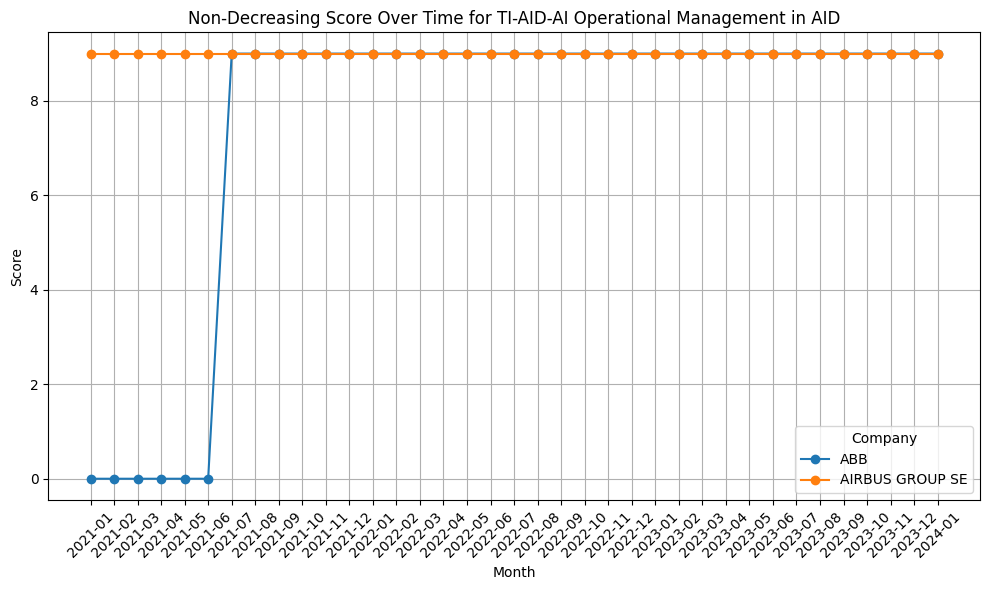

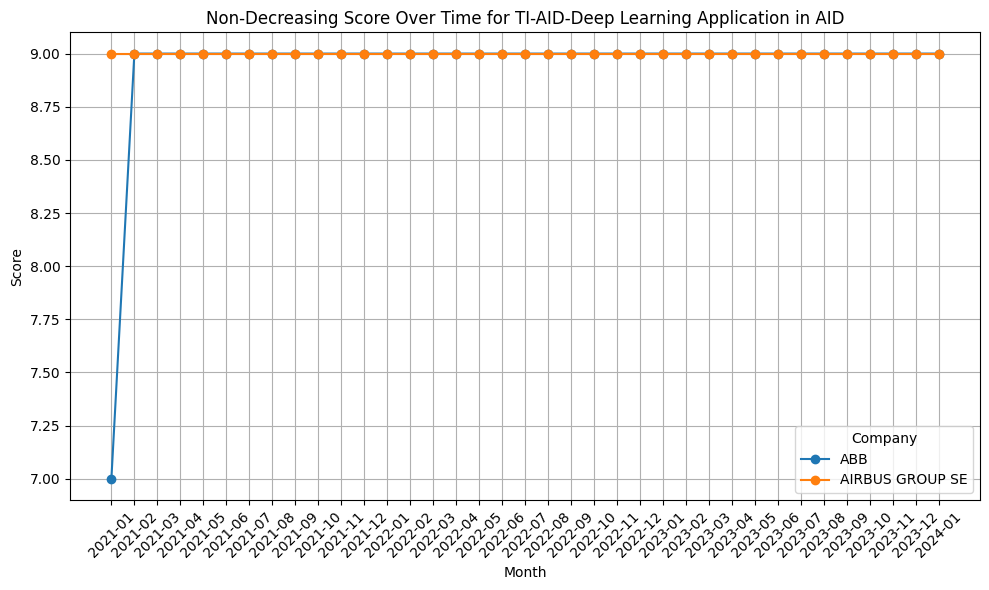

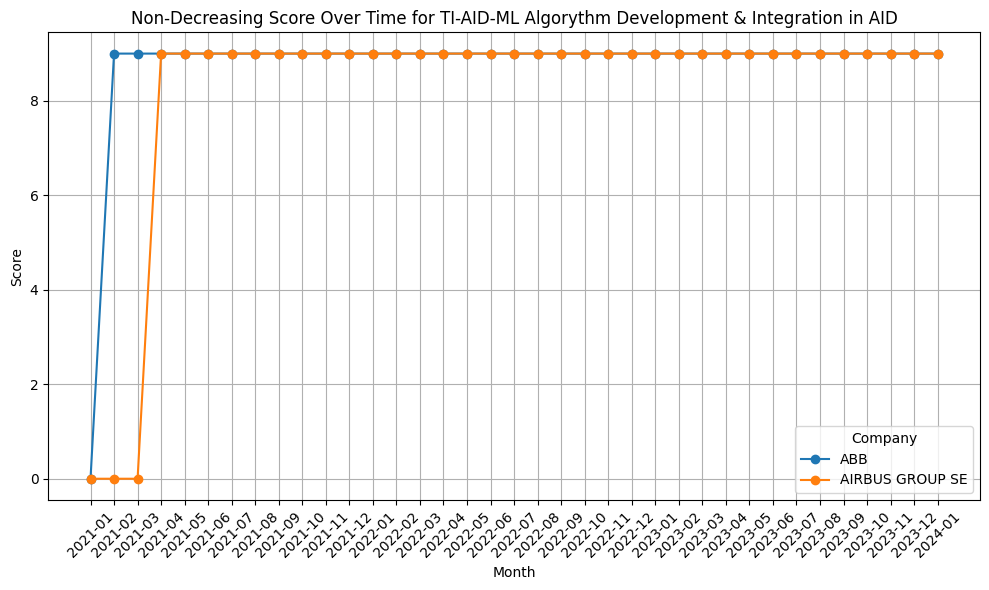

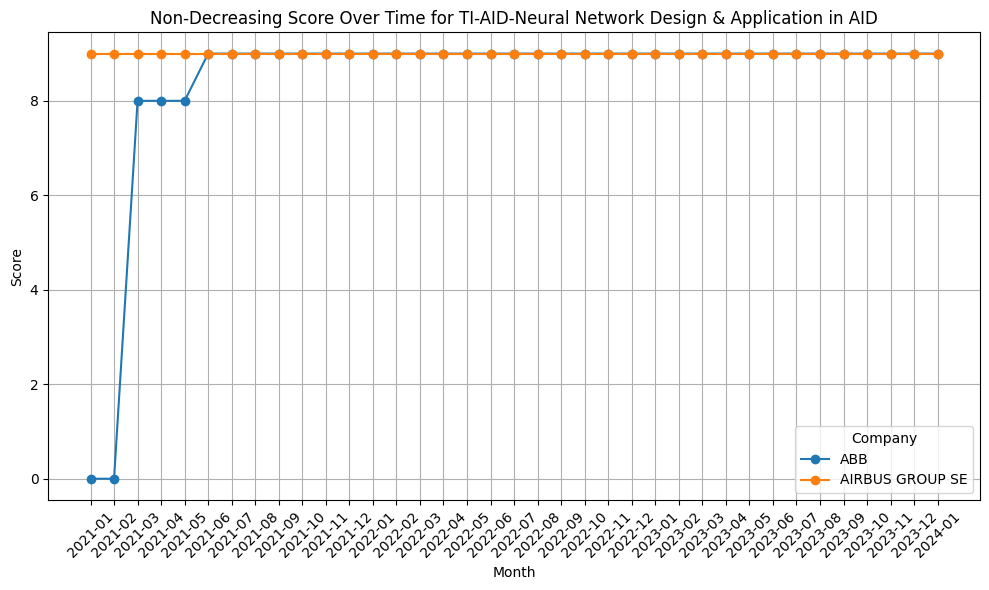

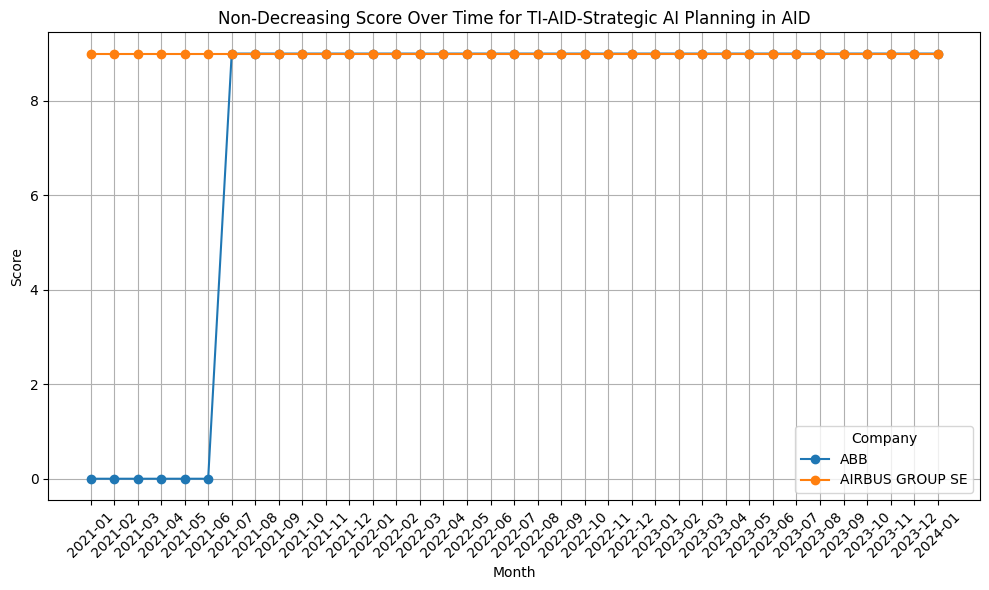

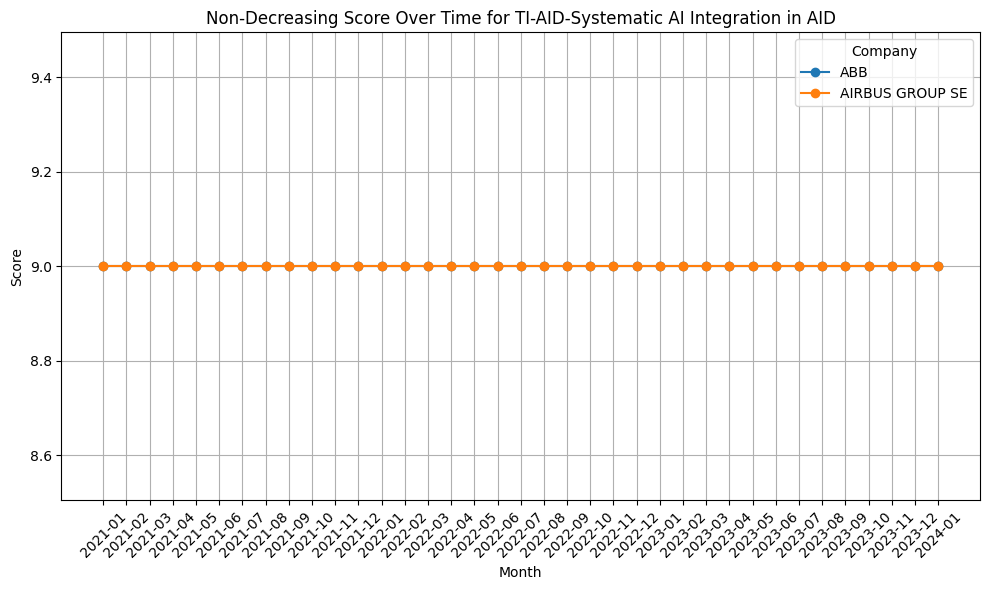

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data frame (assuming 'merged_df' is already loaded)
# merged_df = pd.read_csv('path_to_your_csv_file.csv')

def plot_non_decreasing_scores(df, company1, company2, capability):
    # Filter the DataFrame for the two companies and the specified capability
    filtered_df_BM = df[(df['Company Name Full'].isin([company1, company2])) & (df['capability'] == capability)]
    
    # Pivot the data for plotting with practices
    pivot_df_BM = filtered_df_BM.pivot_table(index=['month', 'practice'], columns='Company Name Full', values='score', aggfunc='mean').unstack('practice')
    
    # Get unique practices
    unique_practices = filtered_df_BM['practice'].unique()
    
    # Create a plot for each practice
    for practice in unique_practices:
        plt.figure(figsize=(10, 6))
        practice_data = pivot_df_BM.xs(practice, level='practice', axis=1)  # Data for the current practice
        
        # Ensure scores do not decrease
        practice_data = practice_data.cummax()  # Apply cumulative max to each column

        # Plot lines for each company
        for company in [company1, company2]:
            if company in practice_data.columns:
                plt.plot(practice_data.index, practice_data[company], marker='o', label=f'{company}')
        
        plt.title(f'Non-Decreasing Score Over Time for {practice} in {capability}')
        plt.xlabel('Month')
        plt.ylabel('Score')
        plt.legend(title='Company')
        plt.grid(True)
        plt.xticks(rotation=45)  # Rotate dates for better visibility
        plt.tight_layout()
        plt.show()

# Usage example
plot_non_decreasing_scores(merged_df, 'ABB', 'AIRBUS GROUP SE', 'AID')


In [48]:
merged_df.to_csv("export_df_ML.csv")

In [63]:
print(merged_df["score"].max())

9


# Hier anfangen

In [45]:
#merged_df = pd.read_csv("/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/Extended_Retail_Data.csv")
merged_df = pd.read_csv("/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv")

Maximaler Refernwert um prozentuale Scores zu ermitteln

In [46]:
# Calculate the maximum possible score for each capability
max_scores_per_capability = merged_df.groupby('capability').agg({'practice': 'nunique'}).reset_index()
max_scores_per_capability['max_score_per_capability'] = max_scores_per_capability['practice'] * 10

# Sum the scores for each company, capability, supersector, pillar, and month
capability_scores = merged_df.groupby(['Company Name Full', 'capability', 'Supersector', 'pillar', 'month'])['score'].sum().reset_index()

# Rename the 'score' column to 'maturity_score' for clarity
capability_scores.rename(columns={'score': 'maturity_score'}, inplace=True)

# Merge the maximum scores for each capability back into the capability_scores DataFrame
final_scores = pd.merge(capability_scores, max_scores_per_capability[['capability', 'max_score_per_capability']], on='capability', how='left')

# Select relevant columns for display
final_scores = final_scores[['Company Name Full', 'capability', 'Supersector', 'pillar', 'month', 'maturity_score', 'max_score_per_capability']]

final_scores.head()




,Company Name Full,capability,Supersector,pillar,month,maturity_score,max_score_per_capability
0,3I GRP,AID,Financial Services,TI,2021-01,0,60
1,3I GRP,AID,Financial Services,TI,2021-02,0,60
2,3I GRP,AID,Financial Services,TI,2021-03,0,60
3,3I GRP,AID,Financial Services,TI,2021-04,0,60
4,3I GRP,AID,Financial Services,TI,2021-05,0,60


In [47]:
final_scores.head()

,Company Name Full,capability,Supersector,pillar,month,maturity_score,max_score_per_capability
0,3I GRP,AID,Financial Services,TI,2021-01,0,60
1,3I GRP,AID,Financial Services,TI,2021-02,0,60
2,3I GRP,AID,Financial Services,TI,2021-03,0,60
3,3I GRP,AID,Financial Services,TI,2021-04,0,60
4,3I GRP,AID,Financial Services,TI,2021-05,0,60


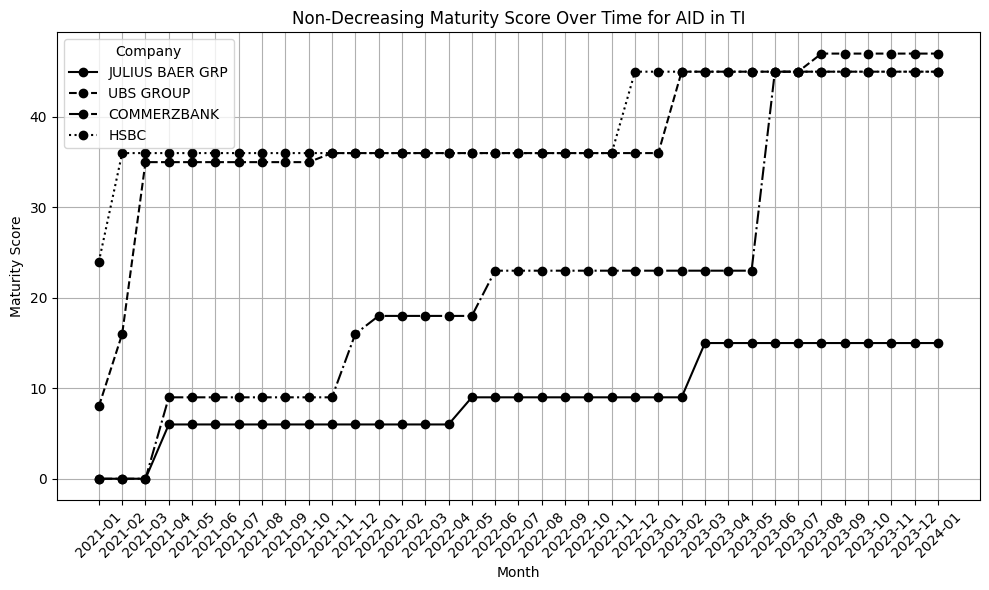

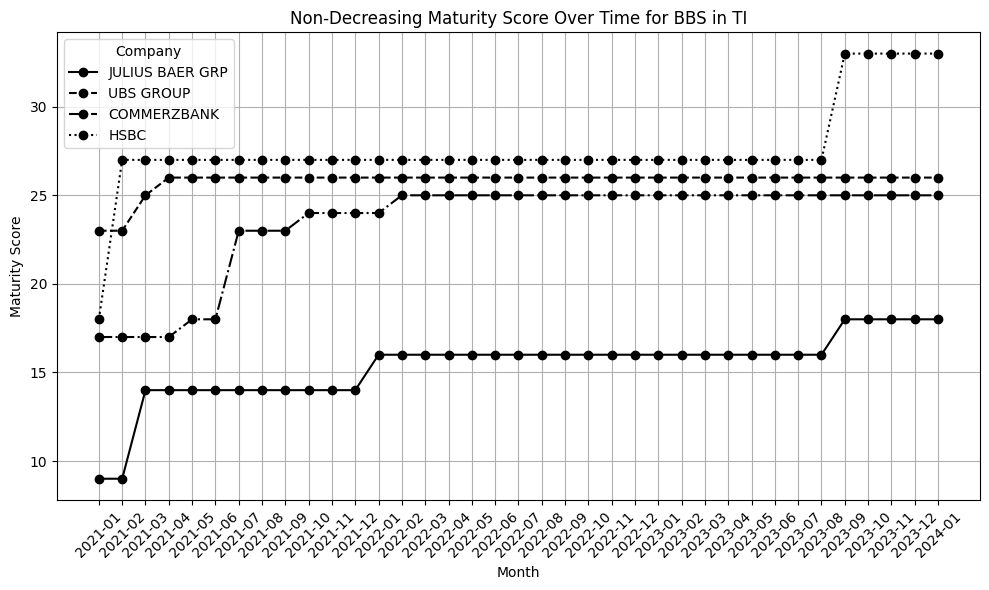

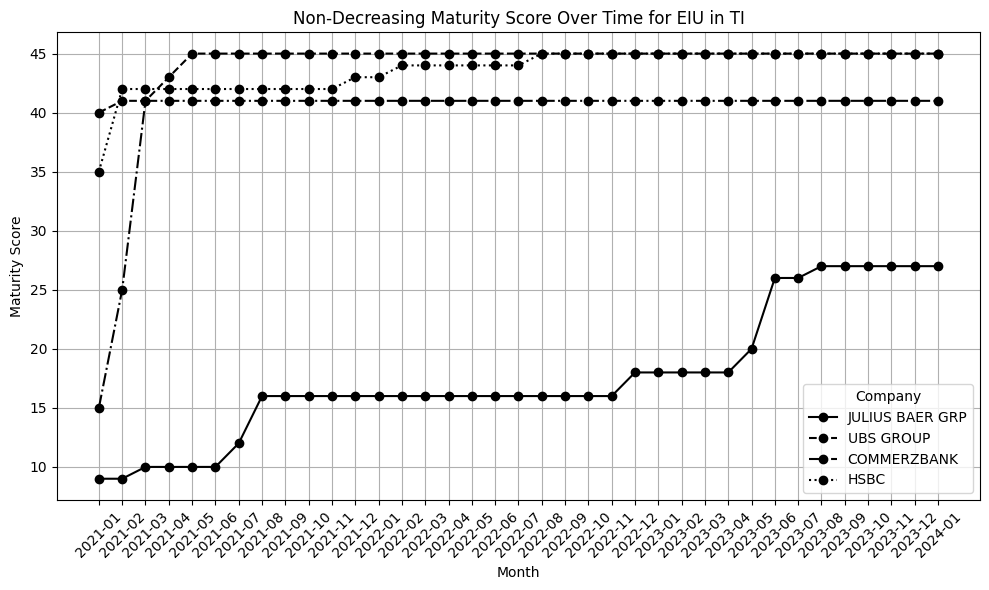

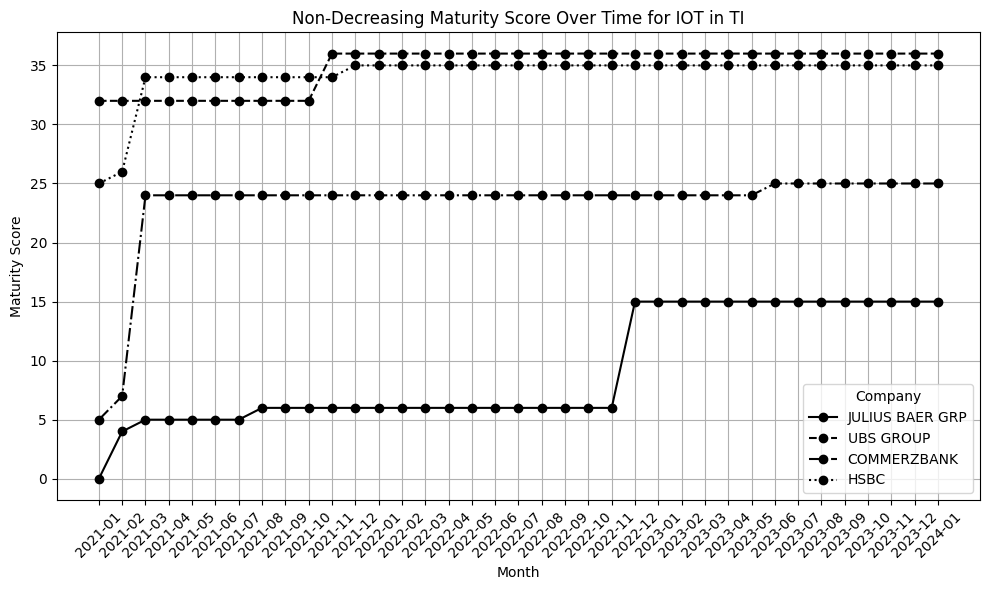

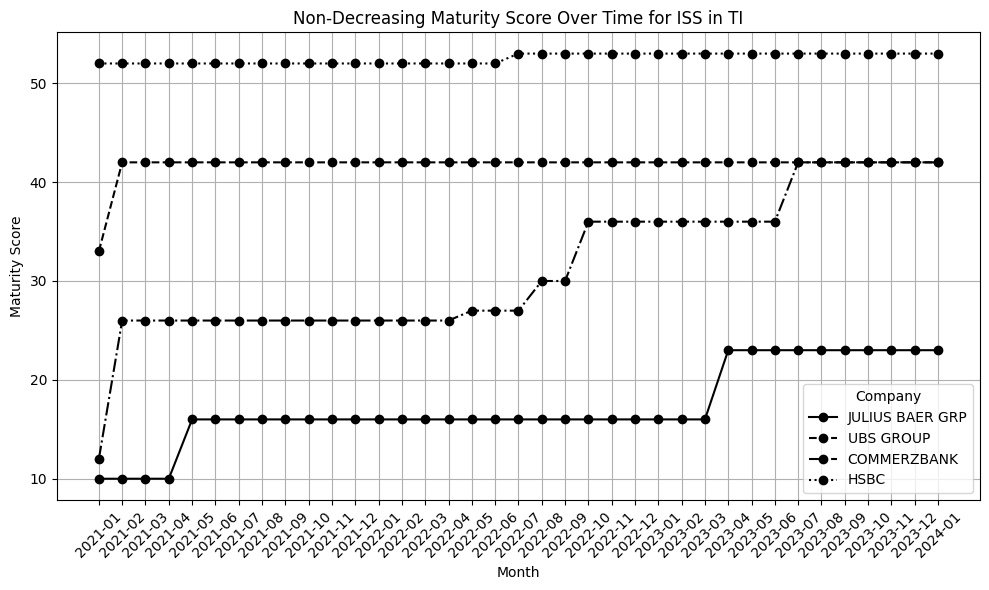

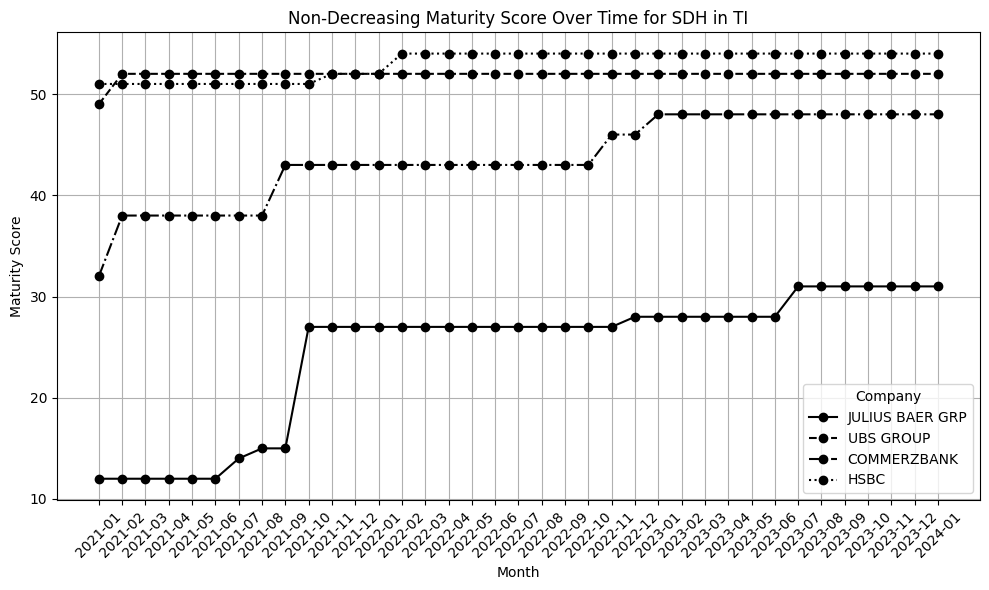

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data frame (assuming 'final_scores' is already loaded)
# final_scores = pd.read_csv('path_to_your_csv_file.csv')

def plot_capability_scores(df, companies, pillar):
    # Filter the DataFrame for the specified companies and pillar
    filtered_df_BM2 = df[(df['Company Name Full'].isin(companies)) & (df['pillar'] == pillar)]
    
    # Pivot the data for plotting with capabilities
    pivot_df_BM2 = filtered_df_BM2.pivot_table(index=['month', 'capability'], columns='Company Name Full', values='maturity_score', aggfunc='mean').unstack('capability')
    
    # Get unique capabilities
    unique_capabilities = filtered_df_BM2['capability'].unique()
    
    # Define line styles for the companies
    line_styles = ['-', '--', '-.', ':']
    
    # Ensure there are enough line styles for the number of companies
    line_styles = (line_styles * (len(companies) // len(line_styles) + 1))[:len(companies)]

    # Create a plot for each capability
    for capability in unique_capabilities:
        plt.figure(figsize=(10, 6))
        capability_data = pivot_df_BM2.xs(capability, level='capability', axis=1)  # Data for the current capability
        
        # Apply cumulative max to ensure scores do not decrease
        capability_data = capability_data.cummax()  # Apply cumulative max to each column

        # Plot lines for each company with the same color but different line styles
        for idx, company in enumerate(companies):
            if company in capability_data.columns:
                plt.plot(capability_data.index, capability_data[company], marker='o', label=f'{company}', color='black', linestyle=line_styles[idx])
        
        plt.title(f'Non-Decreasing Maturity Score Over Time for {capability} in {pillar}')
        plt.xlabel('Month')
        plt.ylabel('Maturity Score')
        plt.legend(title='Company')
        plt.grid(True)
        plt.xticks(rotation=45)  # Rotate dates for better visibility
        plt.tight_layout()
        plt.show()

# Usage example
plot_capability_scores(final_scores, ['JULIUS BAER GRP', 'UBS GROUP', 'COMMERZBANK', 'HSBC'], 'TI')


Ermittlung der Pillar scores baseierend auf den kummulierten Wertend er Capabilities

In [49]:
# Step 1: Sort the DataFrame by company, capability, and month
final_scores_sorted = final_scores.sort_values(by=['Company Name Full', 'capability', 'month'])

# Step 2: Apply a cumulative maximum function to the maturity_score for each capability within each company
final_scores_sorted['adjusted_maturity_score'] = final_scores_sorted.groupby(['Company Name Full', 'capability'])['maturity_score'].cummax()

# Keep Supersector information
final_scores_with_supersector = final_scores_sorted[['Company Name Full', 'pillar', 'Supersector', 'month', 'adjusted_maturity_score', 'max_score_per_capability']]

# Now proceed with the pillar score calculation using the adjusted maturity score
# Sum the adjusted maturity scores and the maximum possible scores for each pillar
pillar_scores = final_scores_with_supersector.groupby(['Company Name Full', 'pillar', 'Supersector', 'month']).agg({
    'adjusted_maturity_score': 'sum', 
    'max_score_per_capability': 'sum'
}).reset_index()

# Calculate the pillar score as the ratio of the total adjusted maturity score to the total maximum score
pillar_scores['pillar_score'] = pillar_scores['adjusted_maturity_score'] / pillar_scores['max_score_per_capability']

# Select relevant columns for display
final_pillar_scores = pillar_scores[['Company Name Full', 'pillar', 'Supersector', 'month', 'pillar_score']]

print(final_pillar_scores)


              Company Name Full pillar         Supersector    month  \
0                        3I GRP    BMI  Financial Services  2021-01   
1                        3I GRP    BMI  Financial Services  2021-02   
2                        3I GRP    BMI  Financial Services  2021-03   
3                        3I GRP    BMI  Financial Services  2021-04   
4                        3I GRP    BMI  Financial Services  2021-05   
...                         ...    ...                 ...      ...   
176485  samhallsbyggnadsbolaget     TI         Real Estate  2023-09   
176486  samhallsbyggnadsbolaget     TI         Real Estate  2023-10   
176487  samhallsbyggnadsbolaget     TI         Real Estate  2023-11   
176488  samhallsbyggnadsbolaget     TI         Real Estate  2023-12   
176489  samhallsbyggnadsbolaget     TI         Real Estate  2024-01   

        pillar_score  
0           0.052381  
1           0.147619  
2           0.176190  
3           0.176190  
4           0.176190  
...      

In [50]:
final_pillar_scores.tail(45)

,Company Name Full,pillar,Supersector,month,pillar_score
176445,samhallsbyggnadsbolaget,PAO,Real Estate,2023-06,0.069231
176446,samhallsbyggnadsbolaget,PAO,Real Estate,2023-07,0.069231
176447,samhallsbyggnadsbolaget,PAO,Real Estate,2023-08,0.069231
176448,samhallsbyggnadsbolaget,PAO,Real Estate,2023-09,0.069231
176449,samhallsbyggnadsbolaget,PAO,Real Estate,2023-10,0.069231
176450,samhallsbyggnadsbolaget,PAO,Real Estate,2023-11,0.069231
176451,samhallsbyggnadsbolaget,PAO,Real Estate,2023-12,0.069231
176452,samhallsbyggnadsbolaget,PAO,Real Estate,2024-01,0.069231
176453,samhallsbyggnadsbolaget,TI,Real Estate,2021-01,0.025714
176454,samhallsbyggnadsbolaget,TI,Real Estate,2021-02,0.074286


In [51]:


# Step 1: Calculate mean pillar score for each company, pillar, and month
monthly_pillar_mean_scores = final_pillar_scores.groupby(['Company Name Full', 'pillar', 'month'])['pillar_score'].mean().reset_index()

# Step 2: Pivot table so each row represents a combination of company and month, and each column represents a pillar
pivot_table_monthly = monthly_pillar_mean_scores.pivot_table(index=['Company Name Full', 'month'], columns='pillar', values='pillar_score').reset_index()

# Step 3: Calculate the overall maturity score for each company per month
# Fill missing values with 0 assuming that not all companies have scores for all 8 pillars every month
pivot_table_monthly_filled = pivot_table_monthly.fillna(0)

# Sum across the pillars for each company and month, divide by 8, and add as a new column
pivot_table_monthly_filled['Overall Maturity Score'] = pivot_table_monthly_filled.iloc[:, 2:].sum(axis=1) / 8

# If you want to keep company names, month, and overall maturity scores
overall_maturity_score_monthly = pivot_table_monthly_filled[['Company Name Full', 'month', 'Overall Maturity Score']]

# Display the new DataFrame
print(overall_maturity_score_monthly)



pillar        Company Name Full    month  Overall Maturity Score
0                        3I GRP  2021-01                0.040931
1                        3I GRP  2021-02                0.075440
2                        3I GRP  2021-03                0.103879
3                        3I GRP  2021-04                0.105383
4                        3I GRP  2021-05                0.111011
...                         ...      ...                     ...
19605   samhallsbyggnadsbolaget  2023-09                0.115813
19606   samhallsbyggnadsbolaget  2023-10                0.119027
19607   samhallsbyggnadsbolaget  2023-11                0.119027
19608   samhallsbyggnadsbolaget  2023-12                0.119027
19609   samhallsbyggnadsbolaget  2024-01                0.119027

[19610 rows x 3 columns]


Stop here

In [78]:


# Group by 'month' and 'Company Name Full' and calculate the mean of 'pillar_score' for each company within each month
overall_maturity_scores = final_pillar_scores.groupby(['month', 'Company Name Full'])['pillar_score'].mean() / 8  # Divide by 8 for 8 pillars

print(overall_maturity_scores)



month    Company Name Full     
2021-01  ABB                       0.031172
         ADIDAS                    0.038417
         ADYEN                     0.005872
         AHOLD                     0.007369
         AIR LIQUIDE               0.007295
                                     ...   
2024-01  VOLKSWAGEN PREF           0.080529
         VOLVO B                   0.073403
         Vonovia SE                0.006313
         WOLTERS KLUWER            0.066290
         ZURICH INSURANCE GROUP    0.055021
Name: pillar_score, Length: 4810, dtype: float64


In [62]:

# Group by 'month' and calculate the mean of 'pillar_score' for each company within each month
overall_maturity_scores = final_pillar_scores.groupby('month')['pillar_score'].mean() / 8  # Divide by 8 for 8 pillars

print(overall_maturity_scores)

month
2021-01    0.021523
2021-02    0.027689
2021-03    0.031190
2021-04    0.033421
2021-05    0.035076
2021-06    0.036261
2021-07    0.037218
2021-08    0.038068
2021-09    0.038927
2021-10    0.039527
2021-11    0.040176
2021-12    0.040657
2022-01    0.041162
2022-02    0.041763
2022-03    0.042247
2022-04    0.042748
2022-05    0.043209
2022-06    0.043649
2022-07    0.043972
2022-08    0.044299
2022-09    0.044679
2022-10    0.044957
2022-11    0.045289
2022-12    0.045587
2023-01    0.045891
2023-02    0.046326
2023-03    0.046689
2023-04    0.046929
2023-05    0.047188
2023-06    0.047407
2023-07    0.047785
2023-08    0.048103
2023-09    0.048404
2023-10    0.048696
2023-11    0.048907
2023-12    0.049082
2024-01    0.049347
Freq: M, Name: pillar_score, dtype: float64


In [72]:
overall_maturity_scores_df = overall_maturity_scores.reset_index(name='Overall Maturity Score')
print(overall_maturity_scores_df)

         month pillar       Company Name Full  Overall Maturity Score
0      2021-01    BMI                     ABB                0.039881
1      2021-01    BMI                  ADIDAS                0.053571
2      2021-01    BMI                   ADYEN                0.010119
3      2021-01    BMI                   AHOLD                0.010119
4      2021-01    BMI             AIR LIQUIDE                0.014881
...        ...    ...                     ...                     ...
48058  2024-01     TI         VOLKSWAGEN PREF                0.095357
48059  2024-01     TI                 VOLVO B                0.082857
48060  2024-01     TI              Vonovia SE                0.008214
48061  2024-01     TI          WOLTERS KLUWER                0.081071
48062  2024-01     TI  ZURICH INSURANCE GROUP                0.068571

[48063 rows x 4 columns]


Proceed here

In [52]:
# Merge the dataframes on 'Company Name Full' and 'month'
final_df= final_pillar_scores.merge(overall_maturity_score_monthly, on=['Company Name Full', 'month'], how='left')

# Print the final DataFrame
print(final_df)


              Company Name Full pillar         Supersector    month  \
0                        3I GRP    BMI  Financial Services  2021-01   
1                        3I GRP    BMI  Financial Services  2021-02   
2                        3I GRP    BMI  Financial Services  2021-03   
3                        3I GRP    BMI  Financial Services  2021-04   
4                        3I GRP    BMI  Financial Services  2021-05   
...                         ...    ...                 ...      ...   
176485  samhallsbyggnadsbolaget     TI         Real Estate  2023-09   
176486  samhallsbyggnadsbolaget     TI         Real Estate  2023-10   
176487  samhallsbyggnadsbolaget     TI         Real Estate  2023-11   
176488  samhallsbyggnadsbolaget     TI         Real Estate  2023-12   
176489  samhallsbyggnadsbolaget     TI         Real Estate  2024-01   

        pillar_score  Overall Maturity Score  
0           0.052381                0.040931  
1           0.147619                0.075440  
2     

not use this !!!

In [12]:
final_df_V2.to_csv("Pillar_scores.csv")

NameError: name 'final_df_V2' is not defined

In [53]:
final_df.head(500)

,Company Name Full,pillar,Supersector,month,pillar_score,Overall Maturity Score
0,3I GRP,BMI,Financial Services,2021-01,0.052381,0.040931
1,3I GRP,BMI,Financial Services,2021-02,0.147619,0.075440
2,3I GRP,BMI,Financial Services,2021-03,0.176190,0.103879
3,3I GRP,BMI,Financial Services,2021-04,0.176190,0.105383
4,3I GRP,BMI,Financial Services,2021-05,0.176190,0.111011
...,...,...,...,...,...,...
495,A2A,DA,Utilities,2022-03,0.084211,0.135166
496,A2A,DA,Utilities,2022-04,0.084211,0.140356
497,A2A,DA,Utilities,2022-05,0.084211,0.140356
498,A2A,DA,Utilities,2022-06,0.084211,0.140952


In [54]:
# Merge the dataframes on 'Company Name Full' and 'month'
final_df = final_pillar_scores.merge(overall_maturity_score_monthly, on=['Company Name Full', 'month'], how='left')

# Select the desired columns
final_df = final_df[['Company Name Full', 'Supersector', 'month', 'Overall Maturity Score']]

# Print the final DataFrame
print(final_df)


              Company Name Full         Supersector    month  \
0                        3I GRP  Financial Services  2021-01   
1                        3I GRP  Financial Services  2021-02   
2                        3I GRP  Financial Services  2021-03   
3                        3I GRP  Financial Services  2021-04   
4                        3I GRP  Financial Services  2021-05   
...                         ...                 ...      ...   
176485  samhallsbyggnadsbolaget         Real Estate  2023-09   
176486  samhallsbyggnadsbolaget         Real Estate  2023-10   
176487  samhallsbyggnadsbolaget         Real Estate  2023-11   
176488  samhallsbyggnadsbolaget         Real Estate  2023-12   
176489  samhallsbyggnadsbolaget         Real Estate  2024-01   

        Overall Maturity Score  
0                     0.040931  
1                     0.075440  
2                     0.103879  
3                     0.105383  
4                     0.111011  
...                        ...  


### Finaler Datensatz mit Unternehmen Sektor und Score pro Monat

In [55]:
final_df.head(500)

,Company Name Full,Supersector,month,Overall Maturity Score
0,3I GRP,Financial Services,2021-01,0.040931
1,3I GRP,Financial Services,2021-02,0.075440
2,3I GRP,Financial Services,2021-03,0.103879
3,3I GRP,Financial Services,2021-04,0.105383
4,3I GRP,Financial Services,2021-05,0.111011
...,...,...,...,...
495,A2A,Utilities,2022-03,0.135166
496,A2A,Utilities,2022-04,0.140356
497,A2A,Utilities,2022-05,0.140356
498,A2A,Utilities,2022-06,0.140952


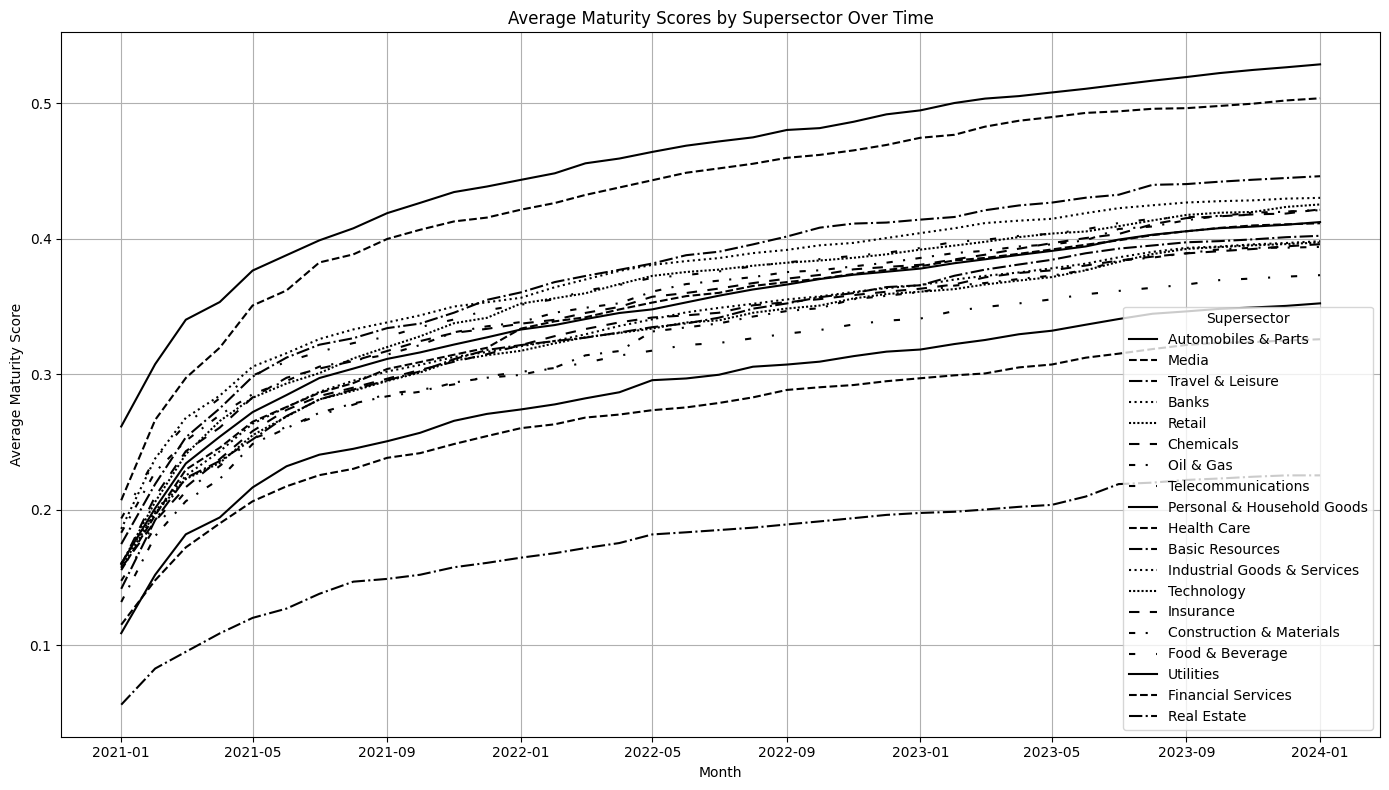

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming final_df is your DataFrame

# Convert 'month' to datetime
final_df['month'] = pd.to_datetime(final_df['month'])

# Calculate the average maturity score for each supersector per month
average_maturity_scores = final_df.groupby(['month', 'Supersector'])['Overall Maturity Score'].mean().unstack()

# Calculate the final average maturity score for each supersector to determine the order in the legend
final_scores = average_maturity_scores.iloc[-1].sort_values(ascending=False)

# Define different line styles for the plot
line_styles = ['-', '--', '-.', ':', (0, (1, 1)), (0, (5, 5)), (0, (3, 5, 1, 5)), (0, (3, 10, 1, 10))]

# Plot the results
plt.figure(figsize=(14, 8))

for i, supersector in enumerate(final_scores.index):
    plt.plot(average_maturity_scores.index, average_maturity_scores[supersector], label=supersector, linestyle=line_styles[i % len(line_styles)], color='black')

plt.title('Average Maturity Scores by Supersector Over Time')
plt.xlabel('Month')
plt.ylabel('Average Maturity Score')
plt.legend(title='Supersector')
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_55581/433428760.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  insurance_df['Maturity Level'] = pd.qcut(insurance_df['Overall Maturity Score'], q=4, labels=['1st Quartile', '2nd Quartile', '3rd Quartile', '4th Quartile'])
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_55581/433428760.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_scores_by_level = insurance_df.groupby(['month', 'Maturity Level'])['Overall Maturity Score'].mean().unstack()


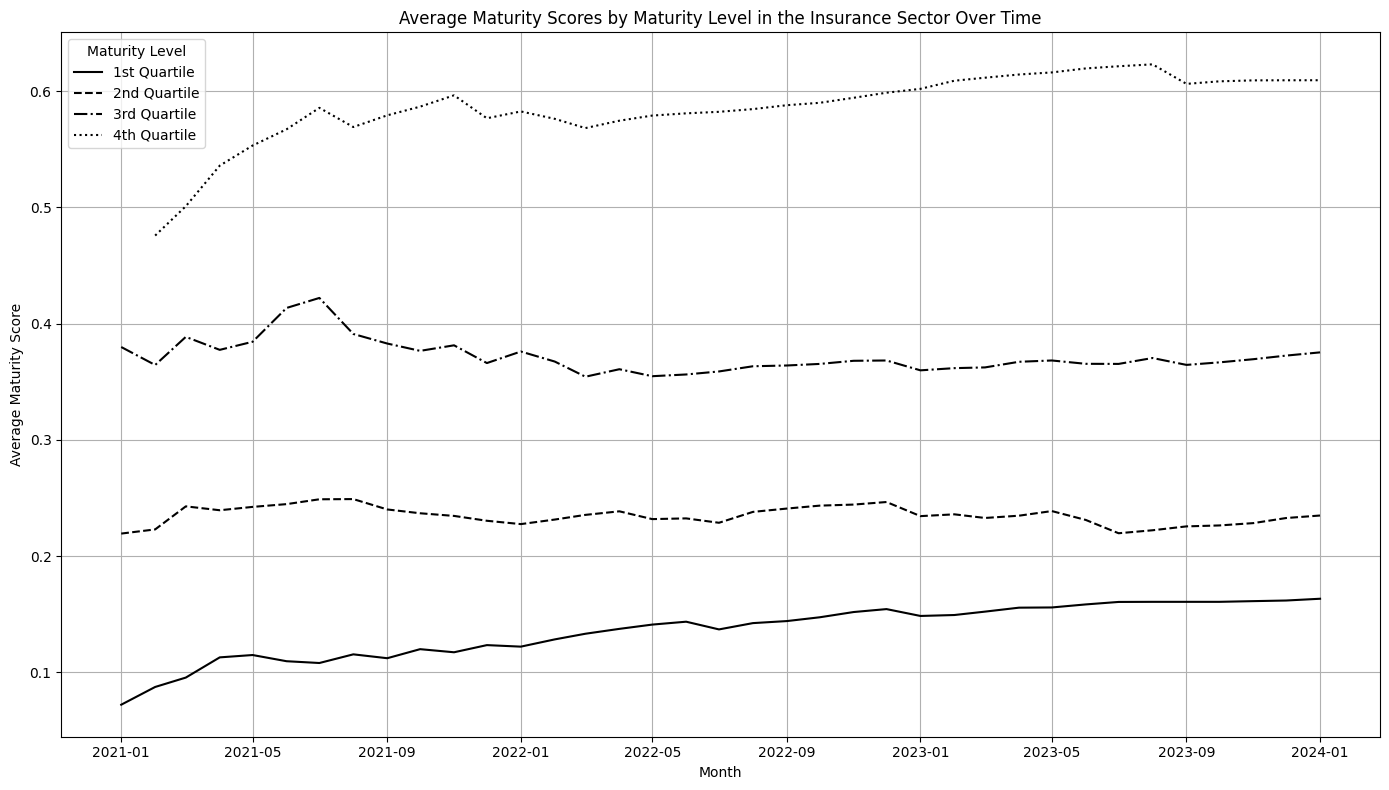

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming final_df is your DataFrame

# Convert 'month' to datetime
final_df['month'] = pd.to_datetime(final_df['month'])

# Filter the data for the Insurance sector
insurance_df = final_df[final_df['Supersector'] == 'Insurance']

# Define the maturity levels (quartiles in this case)
insurance_df['Maturity Level'] = pd.qcut(insurance_df['Overall Maturity Score'], q=4, labels=['1st Quartile', '2nd Quartile', '3rd Quartile', '4th Quartile'])

# Calculate the average maturity score for each group per month
average_scores_by_level = insurance_df.groupby(['month', 'Maturity Level'])['Overall Maturity Score'].mean().unstack()

# Plot the results
plt.figure(figsize=(14, 8))

# Define different line styles for the plot
line_styles = ['-', '--', '-.', ':']

for i, level in enumerate(average_scores_by_level.columns):
    plt.plot(average_scores_by_level.index, average_scores_by_level[level], label=level, linestyle=line_styles[i % len(line_styles)], color='black')

plt.title('Average Maturity Scores by Maturity Level in the Insurance Sector Over Time')
plt.xlabel('Month')
plt.ylabel('Average Maturity Score')
plt.legend(title='Maturity Level')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
final_df.to_csv(Final)

/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_55581/2988349332.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  company_data['month'] = pd.to_datetime(company_data['month'].astype(str), format='%Y-%m')
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_55581/2988349332.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  company_data['month'] = pd.to_datetime(company_data['month'].astype(str), format='%Y-%m')
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_55581/298834933

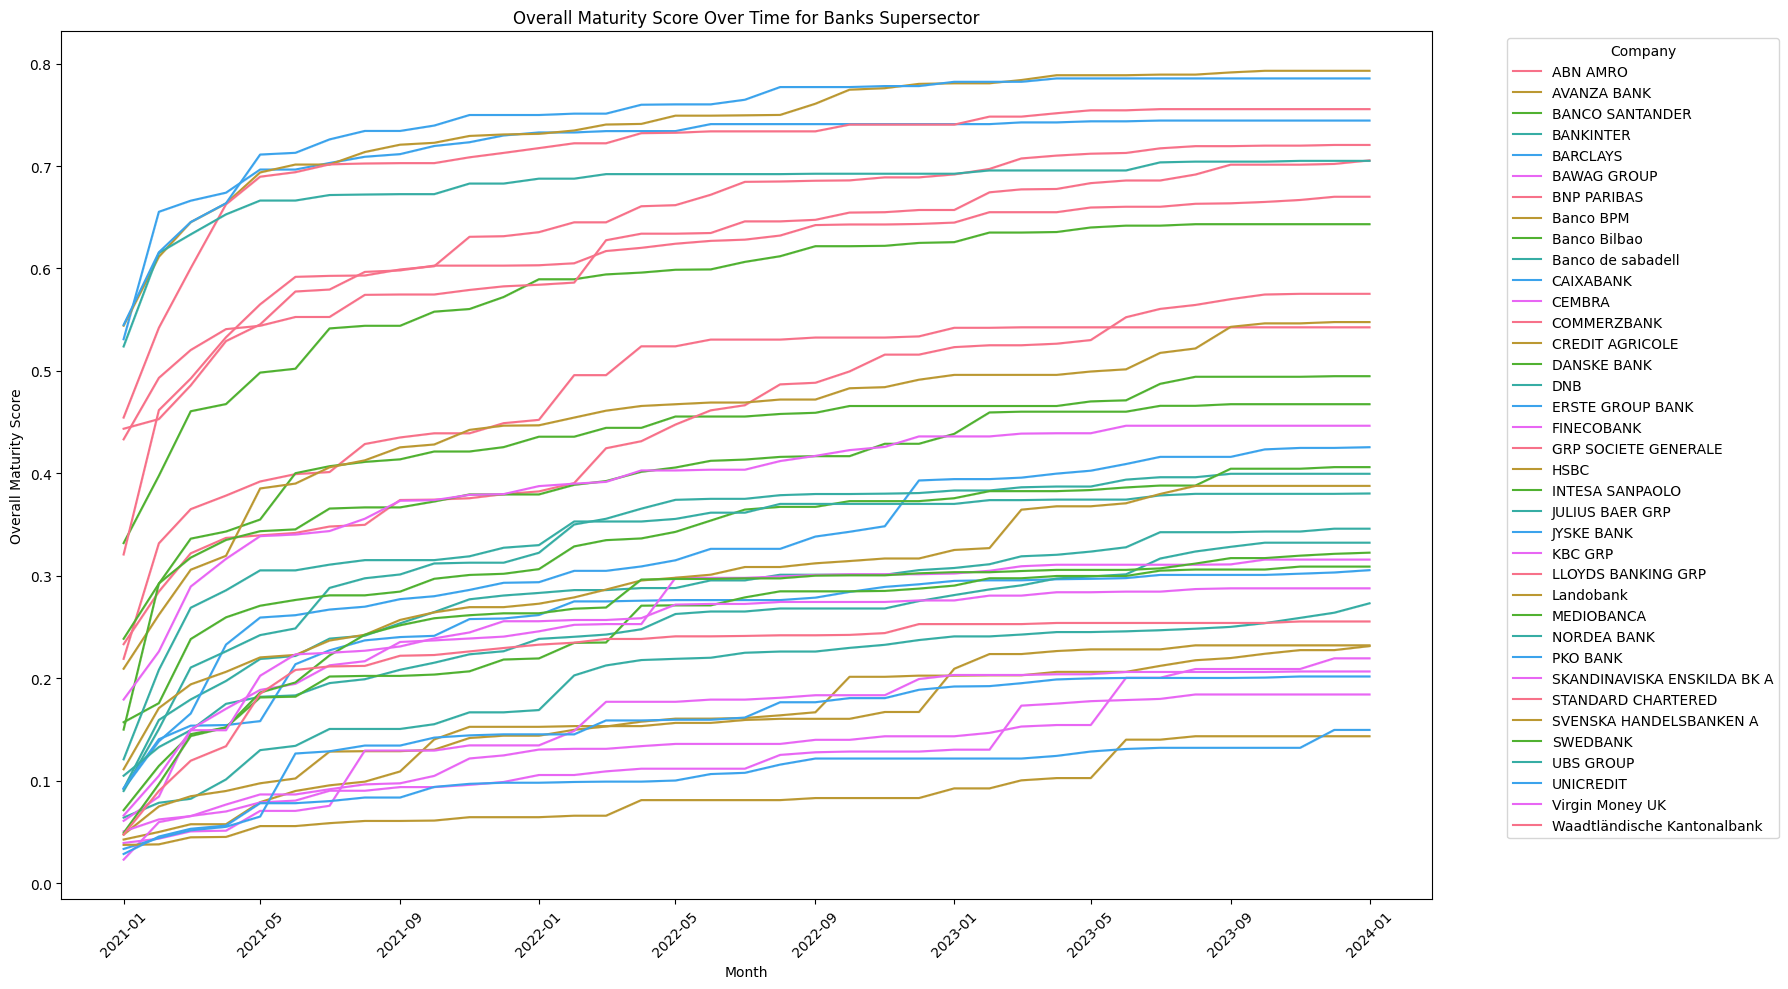

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have a DataFrame named 'final_pillar_scores' with the necessary data
# Replace 'final_pillar_scores' with your actual DataFrame if it's named differently

# Filter the DataFrame for a specific supersector (e.g., 'Industrial Goods & Services')
supersector = 'Banks'
filtered_df = final_df[final_df['Supersector'] == supersector]

# Get unique company names in the filtered DataFrame
companies = filtered_df['Company Name Full'].unique()

# Create a plot for each company
plt.figure(figsize=(18, 10))
sns.set_palette("husl")  # Use a different color for each company

for company in companies:
    company_data = filtered_df[filtered_df['Company Name Full'] == company]
    
    # Convert 'month' column to datetime
    # Convert 'month' column to datetime
    company_data['month'] = pd.to_datetime(company_data['month'].astype(str), format='%Y-%m')

    
    # Plotting overall maturity score per month for the company
    sns.lineplot(data=company_data, x='month', y='Overall Maturity Score', label=company)

# Adding labels and title
plt.title(f'Overall Maturity Score Over Time for {supersector} Supersector')
plt.xlabel('Month')
plt.ylabel('Overall Maturity Score')
plt.xticks(rotation=45)
plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_55581/1852149650.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  company_data['month'] = pd.to_datetime(company_data['month'].astype(str), format='%Y-%m')
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_55581/1852149650.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  company_data['month'] = pd.to_datetime(company_data['month'].astype(str), format='%Y-%m')
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_55581/185214965

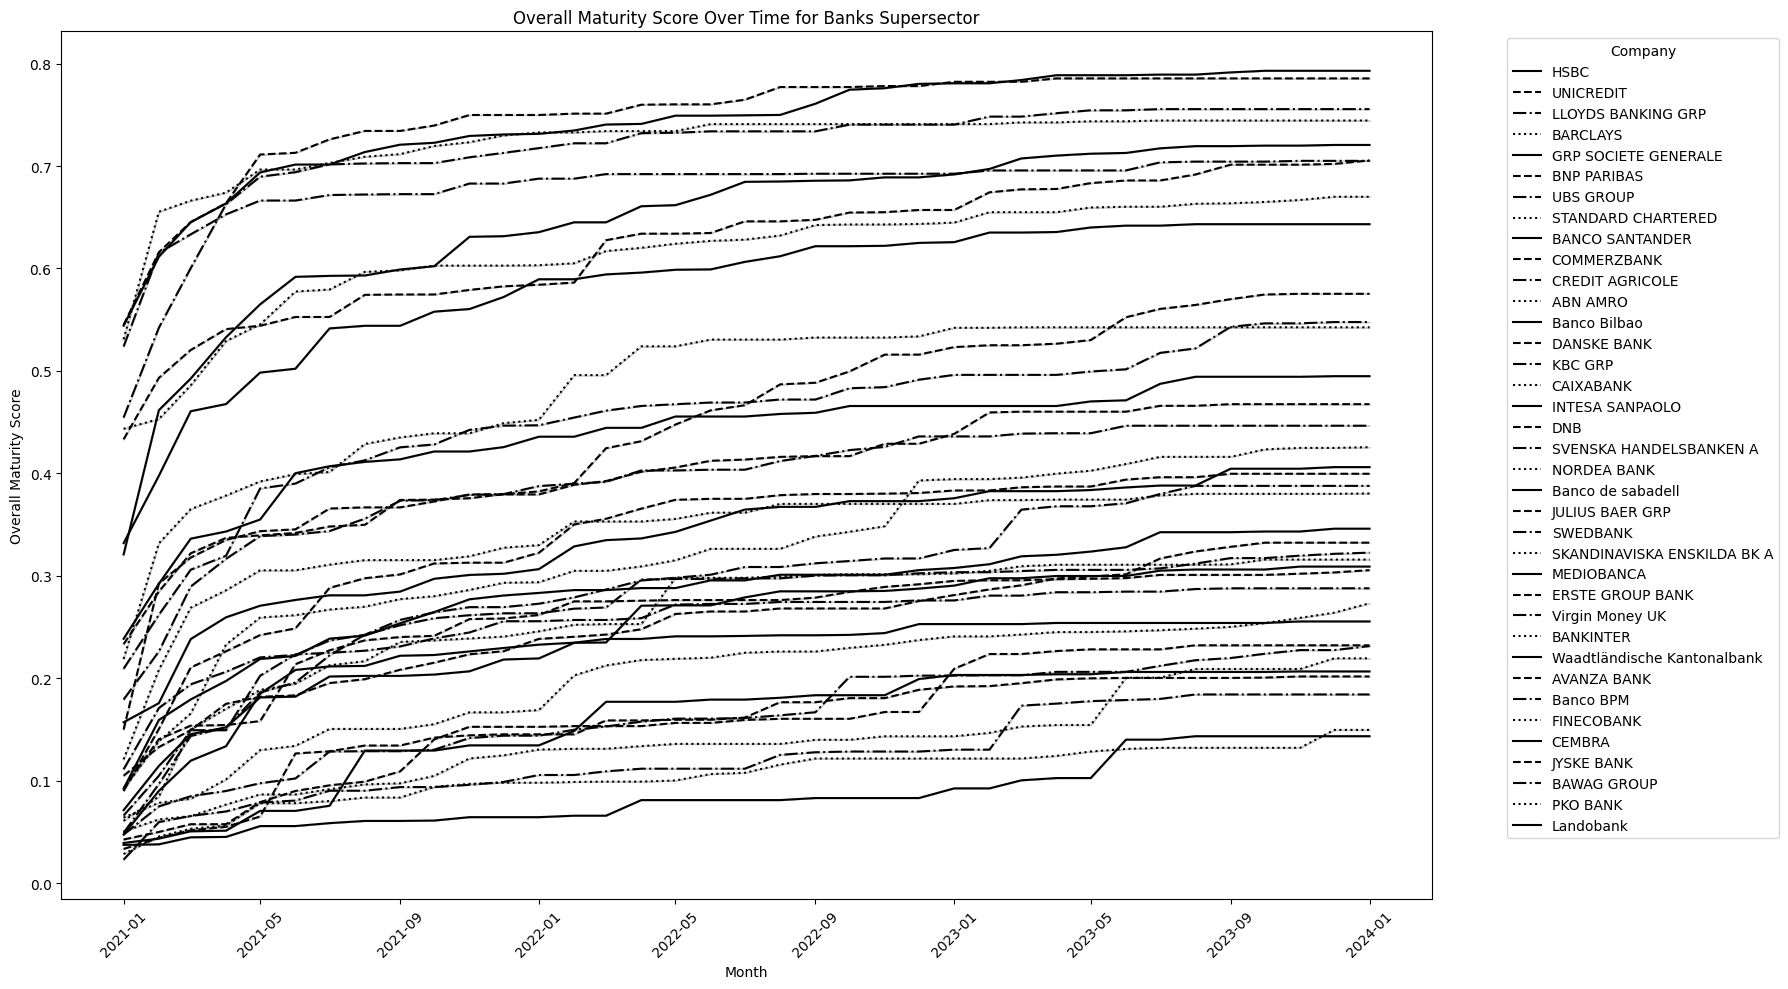

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have a DataFrame named 'final_df' with the necessary data

# Filter the DataFrame for a specific supersector (e.g., 'Banks')
supersector = 'Banks'
filtered_df = final_df[final_df['Supersector'] == supersector]

# Get unique company names in the filtered DataFrame
companies = filtered_df['Company Name Full'].unique()

# Create a dictionary to store the maximum Overall Maturity Score for each company
max_scores = {}

for company in companies:
    company_data = filtered_df[filtered_df['Company Name Full'] == company]
    max_scores[company] = company_data['Overall Maturity Score'].max()

# Sort the companies by their maximum Overall Maturity Score in descending order
sorted_companies = sorted(max_scores, key=max_scores.get, reverse=True)

# Define line styles
line_styles = ['-', '--', '-.', ':']
line_styles = (line_styles * (len(sorted_companies) // len(line_styles) + 1))[:len(sorted_companies)]

# Create a plot for each company
plt.figure(figsize=(18, 10))

# Use a single color for all lines
line_color = 'black'

for idx, company in enumerate(sorted_companies):
    company_data = filtered_df[filtered_df['Company Name Full'] == company]
    
    # Convert 'month' column to datetime
    company_data['month'] = pd.to_datetime(company_data['month'].astype(str), format='%Y-%m')
    
    # Plotting overall maturity score per month for the company
    sns.lineplot(data=company_data, x='month', y='Overall Maturity Score', label=company, color=line_color, linestyle=line_styles[idx])

# Adding labels and title
plt.title(f'Overall Maturity Score Over Time for {supersector} Supersector')
plt.xlabel('Month')
plt.ylabel('Overall Maturity Score')
plt.xticks(rotation=45)
plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_55581/7355403.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  company_data['month'] = pd.to_datetime(company_data['month'].astype(str), format='%Y-%m')


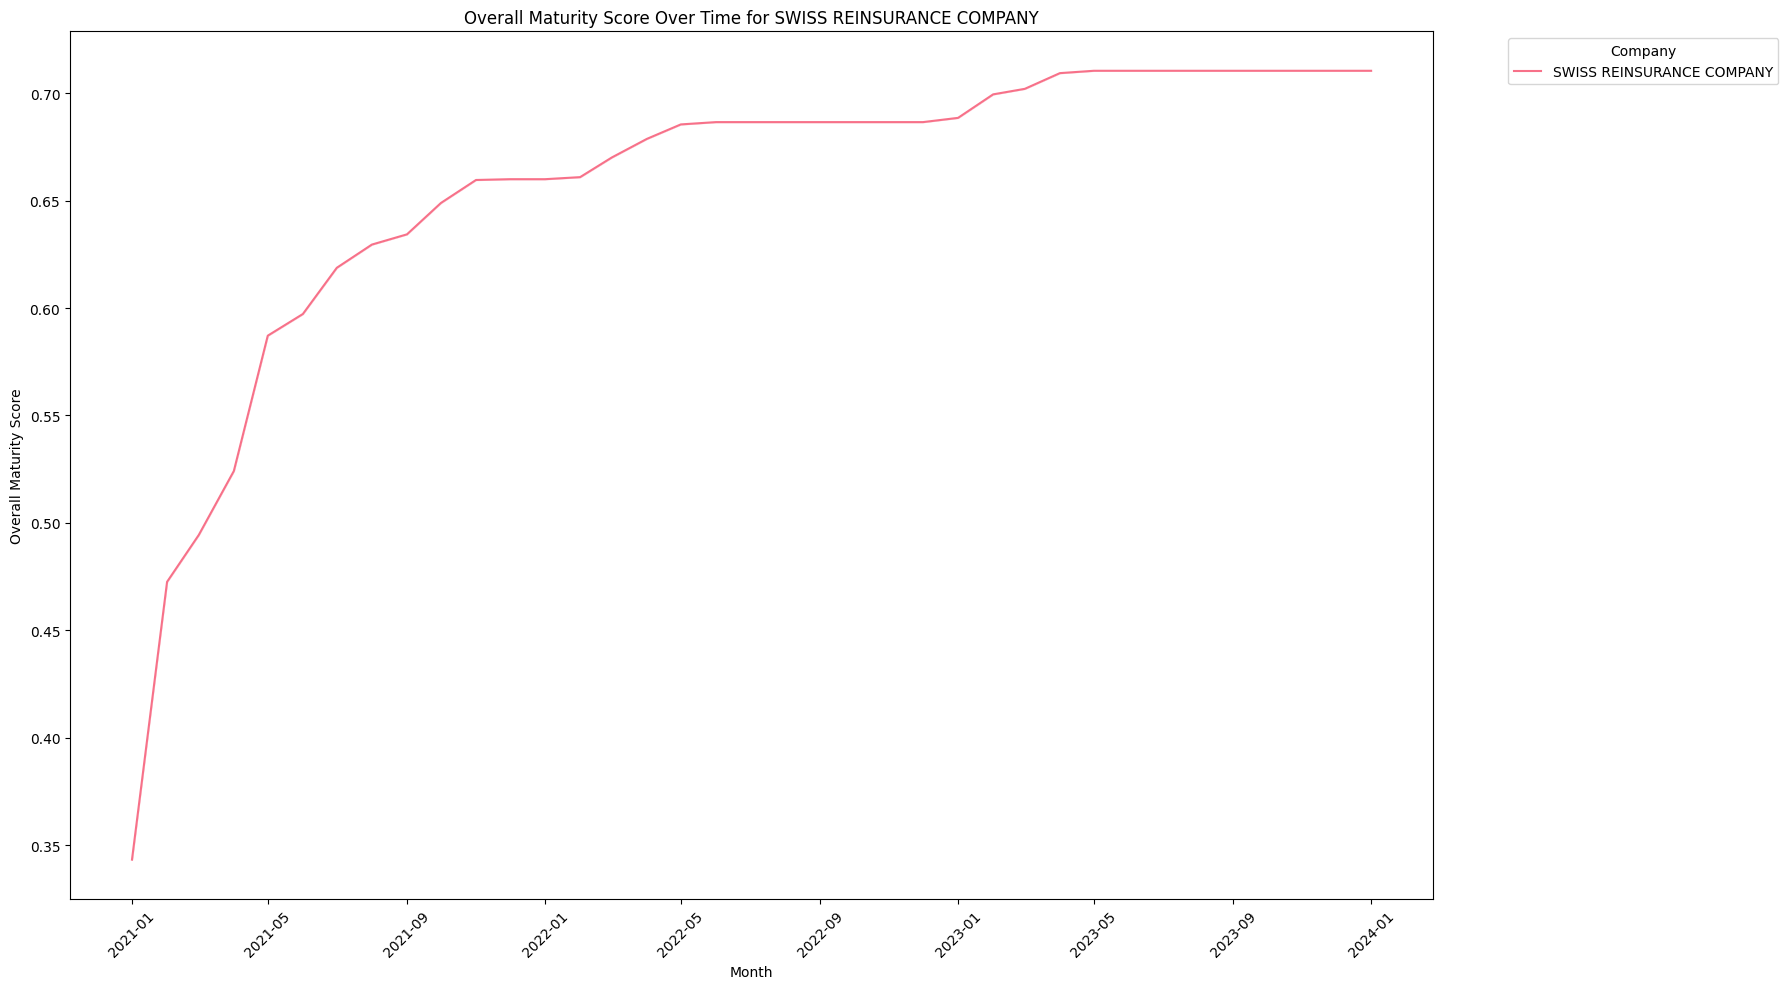

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have a DataFrame named 'final_df' with the necessary data

# Specify the company you are interested in
company_name = 'SWISS REINSURANCE COMPANY'  # Replace with the actual company name

# Filter the DataFrame for the specified company
company_data = final_df[final_df['Company Name Full'] == company_name]

# Convert 'month' column to datetime
company_data['month'] = pd.to_datetime(company_data['month'].astype(str), format='%Y-%m')

# Create a plot for the specified company, adjusting figsize for better readability
plt.figure(figsize=(18, 10))  # Adjusted to make the plot bigger
sns.set_palette("husl")  # Use a different color for each data point (not as critical for a single company)

# Plotting overall maturity score per month for the company
sns.lineplot(data=company_data, x='month', y='Overall Maturity Score', label=company_name)

# Adding labels and title
plt.title(f'Overall Maturity Score Over Time for {company_name}')
plt.xlabel('Month')
plt.ylabel('Overall Maturity Score')
plt.xticks(rotation=45)
plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')

# Improve layout and show the plot
plt.tight_layout()
plt.show()


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_55581/3699578603.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  company_data['month'] = pd.to_datetime(company_data['month'].astype(str), format='%Y-%m')


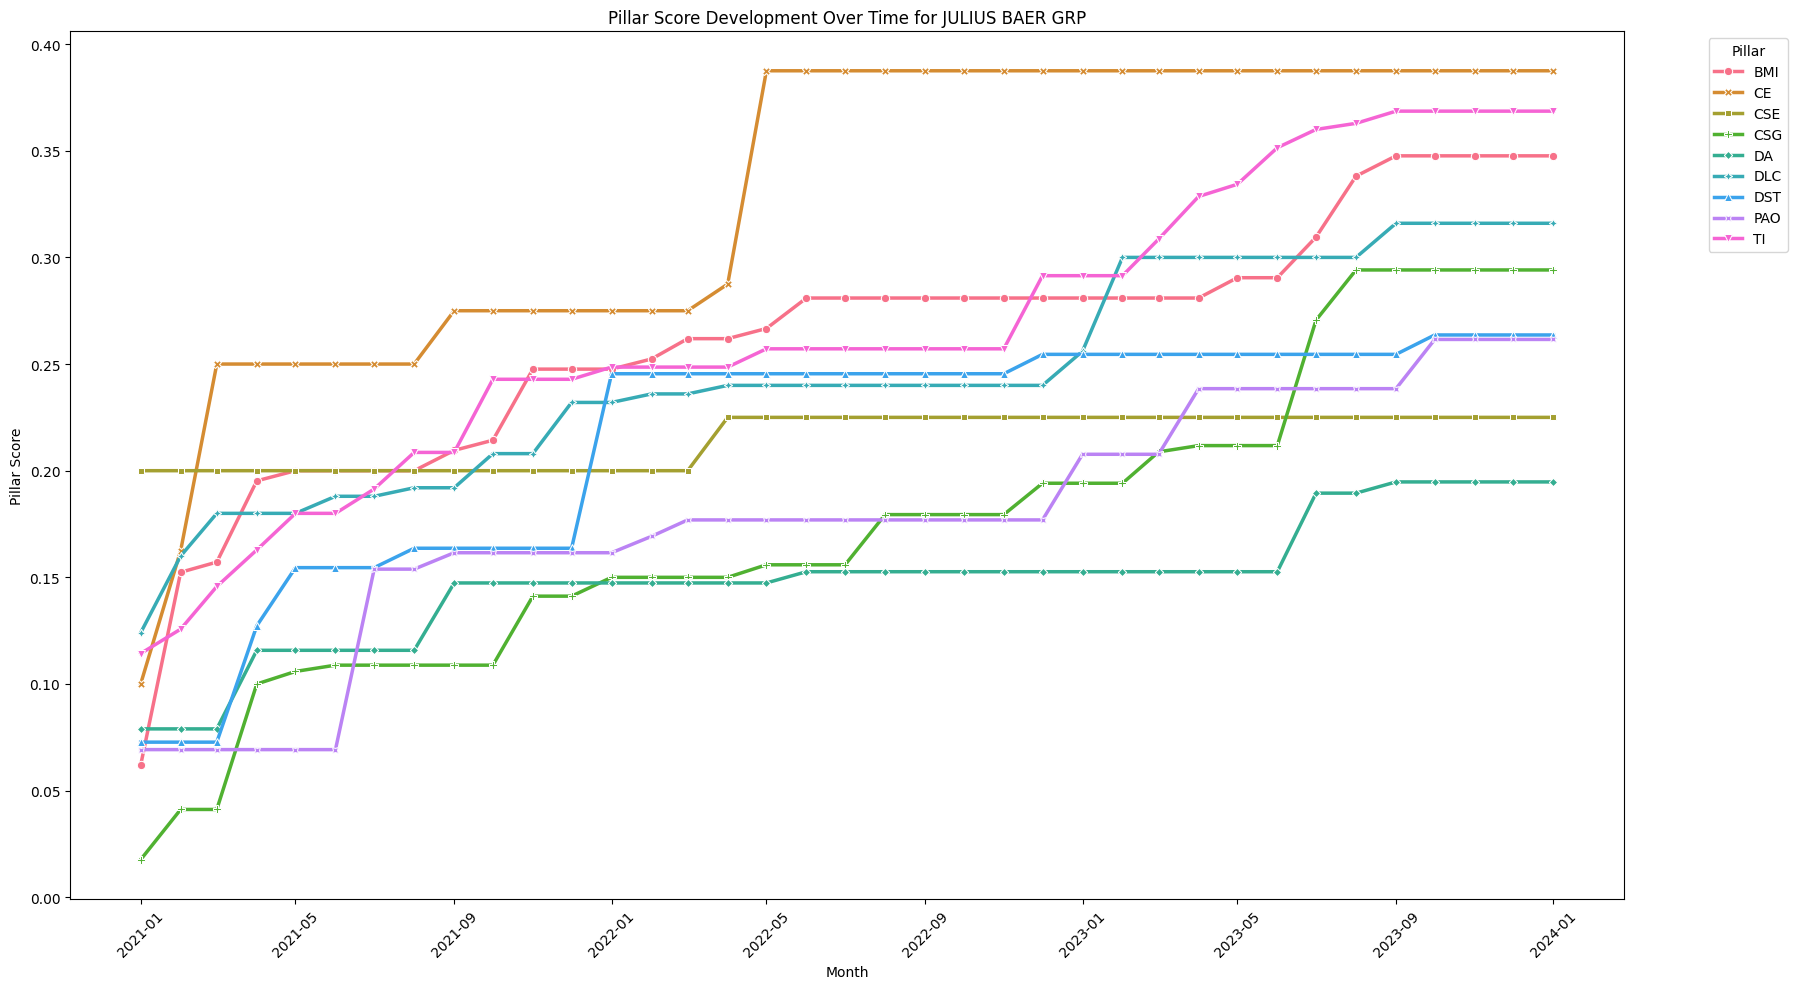

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have a DataFrame named 'final_df' with the necessary data

# Specify the company you are interested in
company_name = 'JULIUS BAER GRP'  # Replace with the actual company name

# Filter the DataFrame for the specified company
company_data = final_pillar_scores[final_pillar_scores['Company Name Full'] == company_name]

# Convert 'month' column to datetime
company_data['month'] = pd.to_datetime(company_data['month'].astype(str), format='%Y-%m')

# Set the figure size and palette for the plot
plt.figure(figsize=(18, 10))  # Adjusted to make the plot bigger
sns.set_palette("husl")  # Use a visually distinct color for each pillar

# Plotting pillar score per month for each pillar in the company's data
sns.lineplot(data=company_data, x='month', y='pillar_score', hue='pillar', style='pillar', markers=True, dashes=False, linewidth=2.5)

# Adding labels, title, and legend
plt.title(f'Pillar Score Development Over Time for {company_name}')
plt.xlabel('Month')
plt.ylabel('Pillar Score')
plt.xticks(rotation=45)
plt.legend(title='Pillar', bbox_to_anchor=(1.05, 1), loc='upper left')

# Improve layout and show the plot
plt.tight_layout()
plt.show()


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_55581/2444434605.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  company_data['month'] = pd.to_datetime(company_data['month'].astype(str), format='%Y-%m')


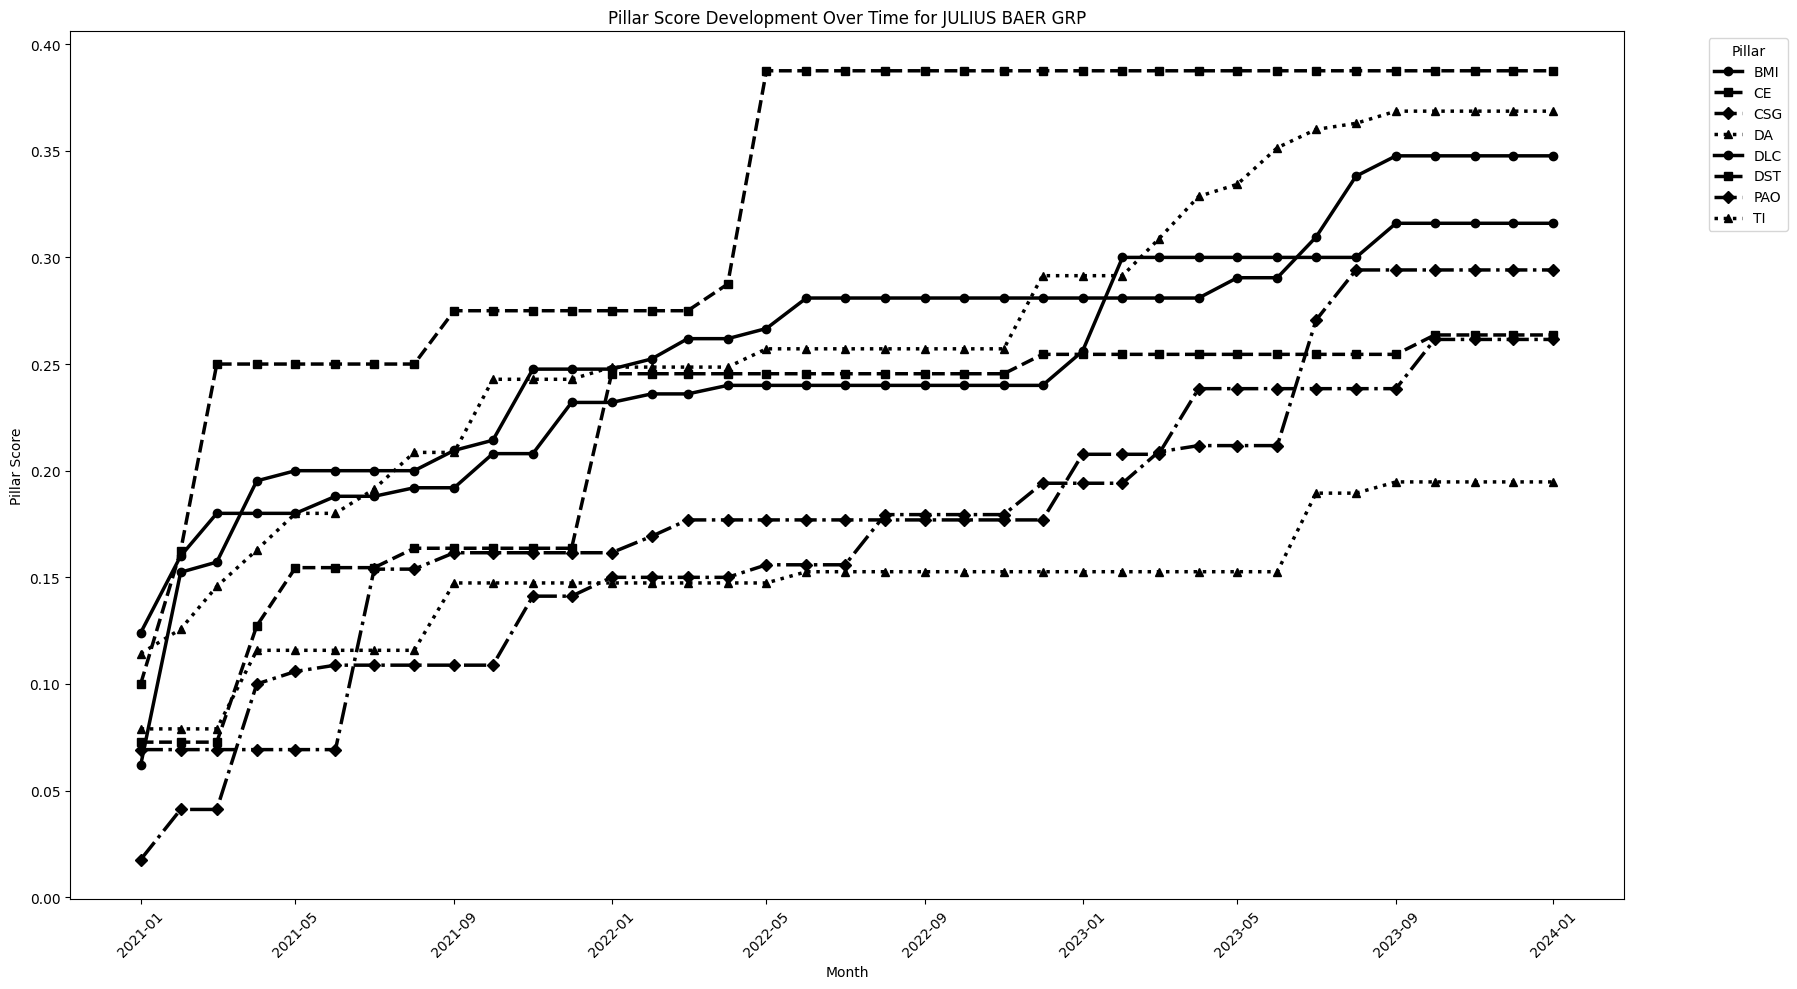

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have a DataFrame named 'final_pillar_scores' with the necessary data

# Specify the company you are interested in
company_name = 'JULIUS BAER GRP'  # Replace with the actual company name

# Filter the DataFrame for the specified company and exclude the pillar 'CSE'
company_data = final_pillar_scores[(final_pillar_scores['Company Name Full'] == company_name) & 
                                   (final_pillar_scores['pillar'] != 'CSE')]

# Convert 'month' column to datetime
company_data['month'] = pd.to_datetime(company_data['month'].astype(str), format='%Y-%m')

# Set the figure size
plt.figure(figsize=(18, 10))

# Define line styles and markers
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^']

# Get unique pillars and assign a line style and marker to each
unique_pillars = company_data['pillar'].unique()
pillar_styles = {pillar: {'linestyle': line_styles[i % len(line_styles)], 'marker': markers[i % len(markers)]} for i, pillar in enumerate(unique_pillars)}

# Plotting pillar score per month for each pillar in the company's data
for pillar in unique_pillars:
    pillar_data = company_data[company_data['pillar'] == pillar]
    plt.plot(pillar_data['month'], pillar_data['pillar_score'], 
             label=pillar, 
             linestyle=pillar_styles[pillar]['linestyle'], 
             color='black', 
             marker=pillar_styles[pillar]['marker'], 
             linewidth=2.5)

# Adding labels, title, and legend
plt.title(f'Pillar Score Development Over Time for {company_name}')
plt.xlabel('Month')
plt.ylabel('Pillar Score')
plt.xticks(rotation=45)
plt.legend(title='Pillar', bbox_to_anchor=(1.05, 1), loc='upper left')

# Improve layout and show the plot
plt.tight_layout()
plt.show()


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have a DataFrame named 'final_pillar_scores' with the necessary data
# Replace 'final_pillar_scores' with your actual DataFrame if it's named differently

# Convert 'month' column to datetime
final_df['month'] = pd.to_datetime(final_df['month'].astype(str), format='%Y-%m')

# Group by 'month' and 'Supersector' and calculate the mean of 'Overall Maturity Score'
average_scores = final_df.groupby(['month', 'Supersector'])['Overall Maturity Score'].mean().reset_index()

# Create the plot
plt.figure(figsize=(18, 10))
sns.set_palette("gray")  # Use a monochrome color palette

# Plotting average maturity score per supersector over time
sns.lineplot(data=average_scores, x='month', y='Overall Maturity Score', hue='Supersector', palette='gray')

# Adding labels and title
plt.title('Average Overall Maturity Score Over Time for All Supersectors')
plt.xlabel('Month')
plt.ylabel('Overall Maturity Score')
plt.xticks(rotation=45)
plt.legend(title='Supersector', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()


ValueError: unconverted data remains when parsing with format "%Y-%m": "-01", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.